In [1]:
import dotenv
%load_ext dotenv
%dotenv

import os
import platform
import json
import random
import time

import jax
import numpy as np
from tqdm import tqdm
import matplotlib.pyplot as plt
from absl import app, flags
from ml_collections import config_flags

from agents import agents
from envs.env_utils import make_env_and_datasets
from utils.datasets import Dataset, ReplayBuffer
from utils.evaluation import evaluate, flatten, supply_rng
from utils.flax_utils import restore_agent

import jax
import numpy as np
import matplotlib.pyplot as plt

def supply_rng(f, rng=jax.random.PRNGKey(0)):
    """Helper function to split the random number generator key before each call to the function."""

    def wrapped(*args, **kwargs):
        nonlocal rng
        rng, key = jax.random.split(rng)
        return f(*args, seed=key, **kwargs)

    return wrapped

/home/jaehyeok/miniconda3/envs/fql/lib/python3.10/site-packages/Cython/Distutils/old_build_ext.py:15: DeprecationWarning: dep_util is Deprecated. Use functions from setuptools instead.
  from distutils.dep_util import newer, newer_group
/home/jaehyeok/miniconda3/envs/fql/lib/python3.10/site-packages/Cython/Distutils/old_build_ext.py:15: DeprecationWarning: dep_util is Deprecated. Use functions from setuptools instead.
  from distutils.dep_util import newer, newer_group
<frozen importlib._bootstrap>:283: DeprecationWarning: the load_module() method is deprecated and slated for removal in Python 3.12; use exec_module() instead
ERROR:2026-01-28 15:27:38,407:jax._src.xla_bridge:444: Jax plugin configuration error: Exception when calling jax_plugins.xla_cuda12.initialize()
Traceback (most recent call last):
  File "/home/jaehyeok/miniconda3/envs/fql/lib/python3.10/site-packages/jax/_src/xla_bridge.py", line 442, in discover_pjrt_plugins
    plugin_module.initialize()
  File "/home/jaehyeok/

In [2]:
# Configuration (following run_fbrac_inner.sh pattern)
task_idx = 4

# Locomotion
env_name = f"antmaze-large-navigate-singletask-task{task_idx}-v0"
# env_name=f"antsoccer-arena-navigate-singletask-task{task_idx}-v0"
env_name = f"humanoidmaze-medium-navigate-singletask-task{task_idx}-v0"

# Manipulation 
env_name = f"cube-single-play-singletask-task{task_idx}-v0"
env_name = f"cube-double-play-singletask-task{task_idx}-v0"
env_name=f"scene-play-singletask-task{task_idx}-v0"
env_name=f"puzzle-3x3-play-singletask-task{task_idx}-v0"
# env_name=f"puzzle-4x4-play-singletask-task{task_idx}-v0"


seed = 0
buffer_size = 2000000
eval_episodes = 10

# Training hyperparameters (from run_fbrac_inner.sh)
alpha = 50
flow_steps = 10
q_agg = "min"
discount = 0.99
batch_size = 256
layer_norm = True
actor_layer_norm = False
offline_steps = 1000000

use_residual=False
layer_width=256
time_embed=16
actor_loss_type='grad'

# ============================================================================
# CRITICAL FOR DETERMINISM: Set PYTHONHASHSEED (matching guidance_evaluation.py)
# ============================================================================
os.environ['PYTHONHASHSEED'] = str(seed)

# Build experiment name and path (following run_fbrac_inner.sh pattern)
if time_embed is None:
    exp_name = f"{env_name}_alpha{alpha}-flow{flow_steps}-qagg{q_agg}-discount{discount}___sd{seed:03d}"
else:
    exp_name = f"{env_name}_alpha{alpha}-flow{flow_steps}-qagg{q_agg}-discount{discount}_time_embed{time_embed}__sd{seed:03d}"
if use_residual:
    base_dir = "residual_ablation"
else:
    base_dir = "default_manipulation"
run_group = env_name
agent_path = f"{base_dir}/fbrac_vd/{run_group}/{exp_name}"
restore_epoch = offline_steps

# Make environment and datasets (BEFORE seeding - matching guidance_evaluation.py order)
env, eval_env, train_dataset, val_dataset = make_env_and_datasets(env_name, frame_stack=None)
train_dataset = Dataset.create(**train_dataset)
train_dataset = ReplayBuffer.create_from_initial_dataset(
    dict(train_dataset), size=max(buffer_size, train_dataset.size + 1)
)

# ============================================================================
# Initialize random seeds AFTER environment creation (matching guidance_evaluation.py)
# ============================================================================
random.seed(seed)
np.random.seed(seed)
master_key = jax.random.PRNGKey(int(seed))

# Seed environment action space for determinism
if hasattr(eval_env, 'action_space'):
    eval_env.action_space.seed(seed)

example_batch = train_dataset.sample(1)

# Load agent config (following run_fbrac_inner.sh pattern)
import importlib.util
agent_config_path = "agents/fbrac_vd.py"
spec = importlib.util.spec_from_file_location("agent_config", agent_config_path)
agent_config_module = importlib.util.module_from_spec(spec)
spec.loader.exec_module(agent_config_module)
agent_config = agent_config_module.get_config()

# Set hyperparameters in config (following run_fbrac_inner.sh pattern)
agent_config.alpha = alpha
agent_config.flow_steps = flow_steps
agent_config.q_agg = q_agg
agent_config.discount = discount
agent_config.batch_size = batch_size
agent_config.layer_norm = layer_norm
agent_config.actor_layer_norm = actor_layer_norm
agent_config.reward_scale = 1.0
agent_config.use_time_decay = False
agent_config.use_time_penalty=False
agent_config.use_time_embed=True
agent_config.time_embed_dim=time_embed
agent_config.normalize_q_loss = False
agent_config.value_hidden_dims = (layer_width,layer_width,layer_width,layer_width)
agent_config.actor_loss_type=actor_loss_type
agent_config.use_residual=use_residual
agent_config.num_ensembles=2

# Create agent (following guidance_evaluation.py pattern)
agent_class = agents[agent_config['agent_name']]
agent = agent_class.create(
    seed,
    example_batch['observations'],
    example_batch['actions'],
    agent_config,
)

# Restore agent (following guidance_evaluation.py pattern)
if agent_path and restore_epoch:
    agent = restore_agent(agent, agent_path, restore_epoch)
    print(f"Agent restored from {agent_path} at epoch {restore_epoch}")

print("Models loaded successfully!")
print(f"✓ Agent: fbrac_inner")
print(f"✓ Environment: {env_name}")
print(f"✓ Master key initialized: {master_key}")
print(f"✓ PYTHONHASHSEED set to: {seed}")
print(f"✓ All seeds set for deterministic evaluation")

KeyboardInterrupt: 

In [142]:
# Evaluation (following main.py pattern)
from utils.evaluation import evaluate

random.seed(seed)
np.random.seed(seed)
os.environ['PYTHONHASHSEED'] = str(seed)
eval_key = jax.random.PRNGKey(int(seed))

eval_episodes = 10

# Evaluate agent (matching main.py lines 202-210)
stats, trajs, renders = evaluate(
    agent=agent,
    env=eval_env,
    config=agent_config,
    num_eval_episodes=eval_episodes,
    num_video_episodes=0,
    video_frame_skip=3,
    compute_eval_critic_loss=False,
    key=eval_key,
)

print(f"Evaluation results:")
for k, v in stats.items():
    print(f"  {k}: {v}")

100%|██████████| 10/10 [00:17<00:00,  1.73s/it]

Evaluation results:
  prev_button_states: 0.9222222222222223
  button_states: 0.9222222222222223
  prev_qpos: -0.1774735057546326
  prev_qvel: -0.006127577632903245
  qpos: -0.17736690842688732
  qvel: 0.00031931062200944775
  control: 35.39720540576523
  time: 21.204999999998957
  success: 0.7
  total.timesteps: 2336.5
  episode.final_reward: -0.7
  episode.return: -1303.0
  episode.length: 419.1
  episode.duration: 1.7319216012954712


In [2]:
def get_success_failure_idx(trajs):
    success_idx = []
    failure_idx = []
    for i in range(len(trajs)):
        if trajs[i]['reward'][-1] != -1:
            success_idx.append(i)
        else:
            failure_idx.append(i)

    return success_idx, failure_idx

def compute_q_values(agent, states, actions, batch_size=256):
    q_values = []
    num_data = states.shape[0]

    for batch_start in tqdm(range(0, num_data, batch_size)):
        batch_end = min(batch_start + batch_size, num_data)
        batch_states = states[batch_start:batch_end]
        batch_actions = actions[batch_start:batch_end]

        # Reshape for broadcasting, if needed
        batch_observations = batch_states.reshape(batch_states.shape[0], -1)
        batch_target_actions = batch_actions.reshape(batch_actions.shape[0], -1)

        qs = agent.network.select('critic')(batch_observations, batch_target_actions).mean(axis=0)
        q_values.extend(qs if np.ndim(qs) == 1 else qs.tolist())

    q_values = np.array(q_values)
    print(q_values.shape)

    return q_values

In [ ]:
success_idx, failure_idx = get_success_failure_idx(trajs)

try:
    success_states = np.concatenate([np.array(x['observation']) for x in np.array(trajs)[success_idx]], axis=0)
    success_actions = np.concatenate([np.array(x['action']) for x in np.array(trajs)[success_idx]], axis=0)
except:
    success_states = np.concatenate([np.array(x['observation']) for x in np.array(trajs)[failure_idx]], axis=0)
    success_actions = np.concatenate([np.array(x['action']) for x in np.array(trajs)[failure_idx]], axis=0)

In [2]:
# ============================================================================
# Experiment 1: Value Consistency Plot (ODE Rollout Verification)
# ============================================================================
# Goal: Verify that the distilled value Q_inner(s, x_t, t) remains constant 
# along the flow trajectory, as predicted by the Transport Equation (dV/dt = 0).
#
# Expected behavior:
# - Q_phi(s, x_t, t) (Blue): Flat horizontal line aligned with V_GT
# - Q_outer(s, x_t) (Red): Erratic at t=0, converging to V_GT near t=1
# - V_GT (Black dotted): The ground truth value of the final clean action
# ============================================================================

import jax.numpy as jnp

def fourier_time_embed(t, embed_dim=64, max_freq=256.0):
    """
    Fourier positional embedding for time.
    Maps scalar t ∈ [0, 1] to a embed_dim-dimensional vector using sinusoidal features.
    
    Args:
        t: Time values of shape (batch, 1)
        embed_dim: Dimension of the embedding (must be even)
        max_freq: Maximum frequency for the Fourier features
        
    Returns:
        Embedding of shape (batch, embed_dim)
    """
    # Frequencies: log-spaced from 1 to max_freq
    half_dim = embed_dim // 2
    freqs = jnp.exp(jnp.linspace(0.0, jnp.log(max_freq), half_dim))
    # Apply frequencies to time: (batch, 1) * (half_dim,) -> (batch, half_dim)
    args = t * freqs[None, :]
    # Concatenate sin and cos: (batch, embed_dim)
    embedding = jnp.concatenate([jnp.sin(args), jnp.cos(args)], axis=-1)
    return embedding

def run_value_consistency_experiment(agent, state, flow_steps, seed=42, batch_size=256):
    """
    Run the value consistency experiment for a single state (BATCHED for speed).
    
    Args:
        agent: The trained fbrac_inner agent
        state: A single observation state (shape: obs_dim,)
        seed: Random seed for reproducibility
        batch_size: Number of noise samples to process in parallel
    
    Returns:
        Dictionary with timesteps, distilled/naive values (mean/std), and ground truth
    """
    rng = jax.random.PRNGKey(seed)
    # flow_steps = agent.config['flow_steps']
    action_dim = agent.config['action_dim']
    
    # Sample all initial noises at once: x_0 ~ N(0, I), shape: (batch_size, action_dim)
    rng, noise_rng = jax.random.split(rng)
    x_0 = jax.random.normal(noise_rng, (batch_size, action_dim))
    
    # Replicate state for batch: (batch_size, obs_dim)
    obs = jnp.tile(state[None, :], (batch_size, 1))
    
    # Initialize x_t with noise
    x_t = x_0  # Shape: (batch_size, action_dim)
    
    # Storage for values at each timestep: lists of (batch_size,) arrays
    all_distilled = []
    all_naive = []
    
    # Perform batched ODE rollout and compute values at each step
    for i in range(flow_steps + 1):
        t = i / flow_steps
        t_arr = jnp.full((batch_size, 1), t)  # Shape: (batch_size, 1)
        
        # --- Compute Distilled Value: Q_phi(s, x_t, t) ---
        # Using tc_critic (time-conditioned critic)
        if time_embed is not None:
            t_feature = fourier_time_embed(t_arr, embed_dim=time_embed)
            q_inner = agent.network.select('tc_critic')(obs, x_t, t_feature)
        else:
            q_inner = agent.network.select('tc_critic')(obs, x_t, t_arr)

        if q_inner.ndim > 1:
            q_inner = q_inner.mean(axis=0)  # Average over ensembles -> (batch_size,)
        all_distilled.append(np.array(q_inner))
        
        # --- Compute Naive Baseline: Q_outer(s, x_t) ---
        q_outer = agent.network.select('critic')(obs, x_t)
        if q_outer.ndim > 1:
            q_outer = q_outer.mean(axis=0)  # Average over ensembles -> (batch_size,)
        all_naive.append(np.array(q_outer))
        
        # --- Flow step (if not at terminal) ---
        if i < flow_steps:
            vels = agent.network.select('actor_bc_flow')(obs, x_t, t_arr)
            x_t = x_t + vels / flow_steps
    
    # --- Ground Truth: Q_outer(s, x_1) ---
    x_1 = jnp.clip(x_t, -1, 1)  # Final clean actions: (batch_size, action_dim)
    q_gt = agent.network.select('critic')(obs, x_1)

    t_arr = jnp.full((batch_size, 1), 1.)
    if time_embed is not None:
        t_arr = fourier_time_embed(t_arr, embed_dim=time_embed)
        
    q_inner_gt = agent.network.select('tc_critic')(obs, x_1, t_arr)
    if q_gt.ndim > 1:
        q_gt = q_gt.mean(axis=0)  # -> (batch_size,)
        q_inner_gt = q_inner_gt.mean(axis=0)
    all_gt = np.array(q_gt)
    all_inner_gt = np.array(q_inner_gt)
    
    # Convert to arrays: (flow_steps+1, batch_size)
    all_distilled = np.array(all_distilled)  # (flow_steps+1, batch_size)
    all_naive = np.array(all_naive)          # (flow_steps+1, batch_size)
    
    # Compute statistics across batch dimension
    timesteps = np.array([i / flow_steps for i in range(flow_steps + 1)])
    distilled_mean = np.mean(all_distilled, axis=1)  # (flow_steps+1,)
    distilled_std = np.std(all_distilled, axis=1)
    naive_mean = np.mean(all_naive, axis=1)
    naive_std = np.std(all_naive, axis=1)
    gt_mean = np.mean(all_gt)
    gt_std = np.std(all_gt)
    inner_gt_mean = np.mean(all_inner_gt)
    inner_gt_std = np.std(all_inner_gt)
    
    return {
        'timesteps': timesteps,
        'distilled_mean': distilled_mean,
        'distilled_std': distilled_std,
        'naive_mean': naive_mean,
        'naive_std': naive_std,
        'gt_mean': gt_mean,
        'gt_std': gt_std,
        'inner_gt_mean': inner_gt_mean,
        'inner_gt_std': inner_gt_std,
        'all_distilled': all_distilled.T,  # (batch_size, flow_steps+1) for compatibility
        'all_naive': all_naive.T,
        'all_gt': all_gt,
        'all_inner_gt': all_inner_gt,
    }


def plot_value_consistency(results, title="Value Consistency Along ODE Trajectory"):
    """
    Plot the value consistency experiment results.
    """
    fig, ax = plt.subplots(figsize=(10, 6))
    
    timesteps = results['timesteps']
    
    # Plot distilled value Q_phi(s, x_t, t) - should be flat
    ax.plot(timesteps, results['distilled_mean'], 'b-', linewidth=2, 
            label=r'$Q_\phi(s, x_t, t)$ (Distilled Inner Critic)')
    ax.fill_between(timesteps, 
                    results['distilled_mean'] - results['distilled_std'],
                    results['distilled_mean'] + results['distilled_std'],
                    alpha=0.2, color='blue')
    
    # Plot naive baseline Q_outer(s, x_t) - should be erratic
    ax.plot(timesteps, results['naive_mean'], 'r-', linewidth=2,
            label=r'$Q_{outer}(s, x_t)$ (Naive Baseline)')
    ax.fill_between(timesteps,
                    results['naive_mean'] - results['naive_std'],
                    results['naive_mean'] + results['naive_std'],
                    alpha=0.2, color='red')
    
    # Plot ground truth V_GT = Q_outer(s, x_1)
    ax.axhline(y=results['gt_mean'], color='black', linestyle='--', linewidth=2,
               label=r'$V_{GT} = Q_{outer}(s, x_1)$ (Ground Truth)')
    ax.axhspan(results['gt_mean'] - results['gt_std'], 
               results['gt_mean'] + results['gt_std'],
               alpha=0.1, color='gray')

    # Plot inner ground truth
    ax.axhline(y=results['inner_gt_mean'], color='green', linestyle='--', linewidth=2,
               label=r'$V_{GT}^{\mathrm{inner}} = V_{\mathrm{inner}}(s, x_1, 1)$ (Inner Ground Truth)')
    ax.axhspan(results['inner_gt_mean'] - results['inner_gt_std'],
               results['inner_gt_mean'] + results['inner_gt_std'],
               alpha=0.1, color='green')

    
    ax.set_xlabel('Timestep $t$', fontsize=12)
    ax.set_ylabel('Value Estimate', fontsize=12)
    ax.set_title(title, fontsize=14)
    ax.legend(loc='best', fontsize=10)
    ax.grid(True, alpha=0.3)
    ax.set_xlim([0, 1])
    
    plt.tight_layout()
    return fig, ax


def plot_absolute_error(results, title="Absolute Error to Ground Truth"):
    """
    Plot the absolute error |V - V_GT| for both distilled and naive baseline.
    For the distilled/inner critic, use all_inner_gt as ground truth.
    """
    fig, ax = plt.subplots(figsize=(8, 5))
    
    timesteps = results['timesteps']
    gt_mean = results['gt_mean']
    
    # Compute absolute errors for each sample, then get mean/std
    # all_distilled: (batch_size, flow_steps+1), all_gt: (batch_size,)
    all_distilled = results['all_distilled']  # (batch_size, flow_steps+1)
    all_naive = results['all_naive']          # (batch_size, flow_steps+1)
    all_gt = results['all_gt']                # (batch_size,)
    all_inner_gt = results['all_inner_gt']    # (batch_size,)

    # For distilled, use all_inner_gt as the ground truth
    distilled_errors = np.abs(all_distilled - all_inner_gt[:, None])  # (batch_size, flow_steps+1)
    # For naive, use original ground truth all_gt
    naive_errors = np.abs(all_naive - all_gt[:, None])                # (batch_size, flow_steps+1)
    
    # Compute mean and std across batch
    distilled_error_mean = np.mean(distilled_errors, axis=0)  # (flow_steps+1,)
    distilled_error_std = np.std(distilled_errors, axis=0)
    naive_error_mean = np.mean(naive_errors, axis=0)
    naive_error_std = np.std(naive_errors, axis=0)
    
    # Plot distilled error
    ax.plot(timesteps, distilled_error_mean, 'b-', linewidth=2, marker='o',
            label=r'$|V^\pi(s, x_t, t) - V^\pi(s, x_1, 1)|$ (Distilled)')
    ax.fill_between(timesteps,
                    distilled_error_mean - distilled_error_std,
                    distilled_error_mean + distilled_error_std,
                    alpha=0.2, color='blue')
    
    # Plot naive error
    ax.plot(timesteps, naive_error_mean, linewidth=2, marker='s',
            color='tab:orange',
            label=r'$|Q_{env}(s, x_t) - Q_{env}(s, x_1)|$ (Naive)')
    ax.fill_between(timesteps,
                    naive_error_mean - naive_error_std,
                    naive_error_mean + naive_error_std,
                    alpha=0.2, color='tab:orange')
    
    # Add zero line for reference
    ax.axhline(y=0, color='black', linestyle='--', linewidth=1, alpha=0.5)
    
    ax.set_xlabel('Time (t)', fontsize=12)
    ax.set_ylabel('Absolute Difference', fontsize=12)
    ax.set_title(title, fontsize=14)
    ax.legend(loc='best', fontsize=10)
    ax.grid(True, alpha=0.3)
    ax.set_xlim([0, 1])
    ax.set_ylim(bottom=0)  # Error is always non-negative
    plt.grid(True)
    
    plt.tight_layout()
    return fig, ax, {
        'distilled_error_mean': distilled_error_mean,
        'distilled_error_std': distilled_error_std,
        'naive_error_mean': naive_error_mean,
        'naive_error_std': naive_error_std,
    }

Configuration:
  - Flow steps: 10
  - Number of states: 32
  - Batch size per state: 1
  - Total samples: 32
  - Action dim: 5
Running experiment over 32 states...


100%|██████████| 32/32 [00:55<00:00,  1.73s/it]


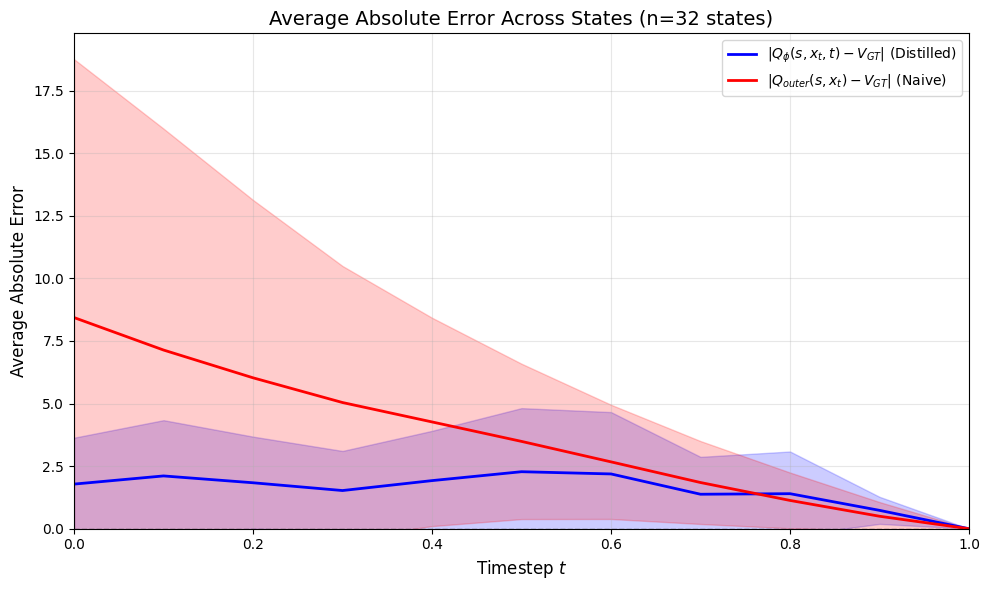


MULTI-STATE ABSOLUTE ERROR STATISTICS
Number of states sampled: 32
Noise samples per state:  1

Distilled Error at t=0:   1.7825 ± 1.8526
Distilled Error at t=1:   0.0000 ± 0.0000
Naive Error at t=0:       8.4339 ± 10.3200
Naive Error at t=1:       0.0000 ± 0.0000

Mean Distilled Error (across all t): 1.5589
Mean Naive Error (across all t):     3.6851

Error Reduction (Naive/Distilled):   2.36x
  → Higher is better (distilled has lower error than naive)


In [123]:
# ============================================================================
# Run the experiment over MULTIPLE STATES
# ============================================================================
# Average absolute error across multiple sampled states to get a robust estimate

def run_multi_state_error_experiment(agent, states, flow_steps, num_states=100, 
                                      batch_size_per_state=32, seed=42):
    """
    Run the value consistency experiment over multiple states and aggregate errors.
    
    Args:
        agent: The trained fbrac_inner agent
        states: Array of states to sample from (num_total_states, obs_dim)
        flow_steps: Number of flow steps for ODE rollout
        num_states: Number of states to sample
        batch_size_per_state: Number of noise samples per state
        seed: Random seed
    
    Returns:
        Dictionary with aggregated error statistics across all states
    """
    np.random.seed(seed)
    rng_seed = seed
    
    num_timesteps = flow_steps + 1
    
    # Sample state indices
    state_indices = np.random.choice(len(states), size=min(num_states, len(states)), replace=False)
    
    # Storage for errors: (num_states, num_timesteps)
    all_distilled_errors = []
    all_naive_errors = []
    
    print(f"Running experiment over {len(state_indices)} states...")
    for i, state_idx in enumerate(tqdm(state_indices)):
        state = states[state_idx]
        rng_seed += 1
        
        # Run experiment for this state
        results = run_value_consistency_experiment(
            agent, state, flow_steps=flow_steps, seed=rng_seed, batch_size=batch_size_per_state
        )
        
        # Compute per-sample errors for this state
        all_distilled = results['all_distilled']  # (batch_size, flow_steps+1)
        all_naive = results['all_naive']          # (batch_size, flow_steps+1)
        all_gt = results['all_gt']                # (batch_size,)
        all_inner_gt = results['all_inner_gt']
        
        # Absolute errors per sample
        distilled_errors = np.abs(all_distilled - all_inner_gt[:, None])  # (batch_size, flow_steps+1)
        naive_errors = np.abs(all_naive - all_gt[:, None])          # (batch_size, flow_steps+1)
        
        # Store mean errors across noise samples for this state
        all_distilled_errors.append(np.mean(distilled_errors, axis=0))  # (flow_steps+1,)
        all_naive_errors.append(np.mean(naive_errors, axis=0))
    
    # Convert to arrays: (num_states, flow_steps+1)
    all_distilled_errors = np.array(all_distilled_errors)
    all_naive_errors = np.array(all_naive_errors)
    
    # Compute statistics across states
    timesteps = np.array([i / flow_steps for i in range(num_timesteps)])
    
    return {
        'timesteps': timesteps,
        'distilled_error_mean': np.mean(all_distilled_errors, axis=0),
        'distilled_error_std': np.std(all_distilled_errors, axis=0),
        'naive_error_mean': np.mean(all_naive_errors, axis=0),
        'naive_error_std': np.std(all_naive_errors, axis=0),
        'all_distilled_errors': all_distilled_errors,  # (num_states, flow_steps+1)
        'all_naive_errors': all_naive_errors,
        'num_states': len(state_indices),
    }


def plot_multi_state_error(results, title="Average Absolute Error Across States"):
    """
    Plot the average absolute error across multiple states.
    """
    fig, ax = plt.subplots(figsize=(10, 6))
    
    timesteps = results['timesteps']
    
    # Plot distilled error
    ax.plot(timesteps, results['distilled_error_mean'], 'b-', linewidth=2,
            label=r'$|Q_\phi(s, x_t, t) - V_{GT}|$ (Distilled)')
    ax.fill_between(timesteps,
                    results['distilled_error_mean'] - results['distilled_error_std'],
                    results['distilled_error_mean'] + results['distilled_error_std'],
                    alpha=0.2, color='blue')
    
    # Plot naive error
    ax.plot(timesteps, results['naive_error_mean'], 'r-', linewidth=2,
            label=r'$|Q_{outer}(s, x_t) - V_{GT}|$ (Naive)')
    ax.fill_between(timesteps,
                    results['naive_error_mean'] - results['naive_error_std'],
                    results['naive_error_mean'] + results['naive_error_std'],
                    alpha=0.2, color='red')
    
    # Add zero line for reference
    ax.axhline(y=0, color='black', linestyle='--', linewidth=1, alpha=0.5)
    
    ax.set_xlabel('Timestep $t$', fontsize=12)
    ax.set_ylabel('Average Absolute Error', fontsize=12)
    ax.set_title(f"{title} (n={results['num_states']} states)", fontsize=14)
    ax.legend(loc='best', fontsize=10)
    ax.grid(True, alpha=0.3)
    ax.set_xlim([0, 1])
    ax.set_ylim(bottom=0)
    
    plt.tight_layout()
    return fig, ax


# ============================================================================
# Run experiment
# ============================================================================
flow_steps_eval = 10  # Number of flow steps for evaluation
num_states_to_sample = 32  # Number of states to average over
batch_size_per_state = 1  # Number of noise samples per state

print(f"Configuration:")
print(f"  - Flow steps: {flow_steps_eval}")
print(f"  - Number of states: {num_states_to_sample}")
print(f"  - Batch size per state: {batch_size_per_state}")
print(f"  - Total samples: {num_states_to_sample * batch_size_per_state}")
print(f"  - Action dim: {agent.config['action_dim']}")

# Run multi-state experiment
multi_state_results = run_multi_state_error_experiment(
    agent, 
    success_states, 
    flow_steps=flow_steps_eval,
    num_states=num_states_to_sample,
    batch_size_per_state=batch_size_per_state,
    seed=42
)

# Plot results
fig, ax = plot_multi_state_error(multi_state_results)
plt.show()

# Print summary statistics
print("\n" + "="*60)
print("MULTI-STATE ABSOLUTE ERROR STATISTICS")
print("="*60)
print(f"Number of states sampled: {multi_state_results['num_states']}")
print(f"Noise samples per state:  {batch_size_per_state}")
print(f"\nDistilled Error at t=0:   {multi_state_results['distilled_error_mean'][0]:.4f} ± {multi_state_results['distilled_error_std'][0]:.4f}")
print(f"Distilled Error at t=1:   {multi_state_results['distilled_error_mean'][-1]:.4f} ± {multi_state_results['distilled_error_std'][-1]:.4f}")
print(f"Naive Error at t=0:       {multi_state_results['naive_error_mean'][0]:.4f} ± {multi_state_results['naive_error_std'][0]:.4f}")
print(f"Naive Error at t=1:       {multi_state_results['naive_error_mean'][-1]:.4f} ± {multi_state_results['naive_error_std'][-1]:.4f}")
print(f"\nMean Distilled Error (across all t): {np.mean(multi_state_results['distilled_error_mean']):.4f}")
print(f"Mean Naive Error (across all t):     {np.mean(multi_state_results['naive_error_mean']):.4f}")
error_reduction = np.mean(multi_state_results['naive_error_mean']) / (np.mean(multi_state_results['distilled_error_mean']) + 1e-8)
print(f"\nError Reduction (Naive/Distilled):   {error_reduction:.2f}x")
print("  → Higher is better (distilled has lower error than naive)")


Running Value Consistency Experiment...
  - Sampled state index: 2732
  - State shape: (55,)
  - Flow steps: 10
  - Action dim: 5


2026-01-07 19:15:57.702976: W external/xla/xla/service/gpu/autotuning/dot_search_space.cc:200] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs?Working around this by using the full hints set instead.
2026-01-07 19:15:58.443997: W external/xla/xla/service/gpu/autotuning/dot_search_space.cc:200] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs?Working around this by using the full hints set instead.
2026-01-07 19:15:59.131982: W external/xla/xla/service/gpu/autotuning/dot_search_space.cc:200] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs?Working around this by using the full hints set instead.


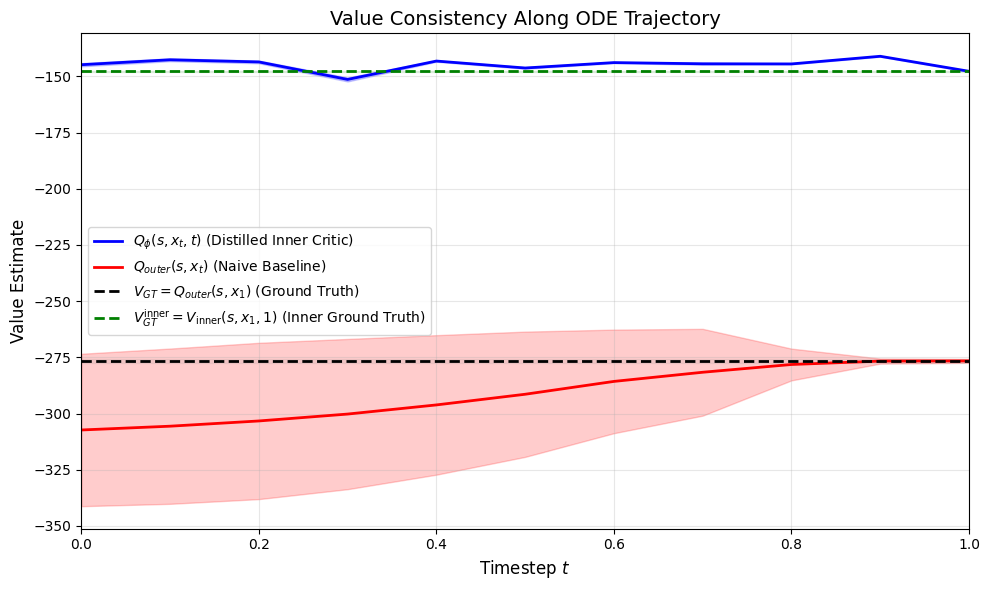

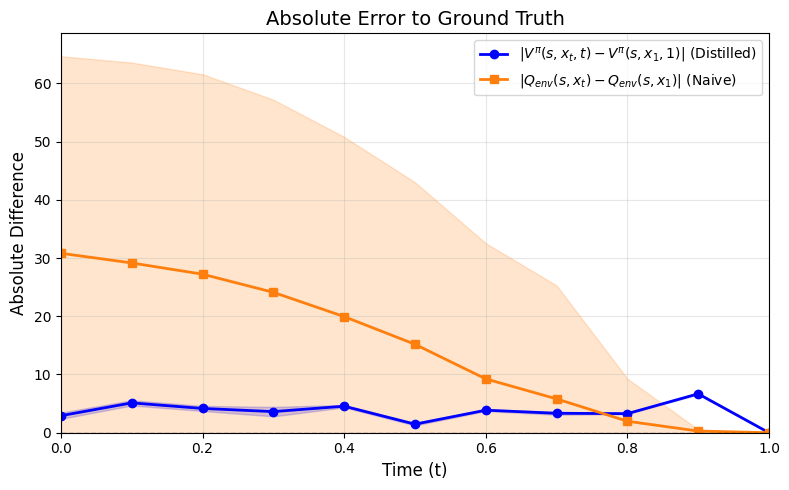


SUMMARY STATISTICS
Ground Truth V_GT:           -276.5902 ± 0.8226
Distilled Value at t=0:      -144.8077 ± 0.7192
Distilled Value at t=1:      -147.7303 ± 0.2429
Naive Baseline at t=0:       -307.3223 ± 33.9118
Naive Baseline at t=1:       -276.5902 ± 0.8226

Distilled Value Range:       [-151.3565, -141.0480]
Naive Baseline Range:        [-307.3223, -276.5902]

Value Consistency (std of distilled across t): 2.6619
  → Lower is better (flat line = perfect consistency)

ABSOLUTE ERROR STATISTICS
Distilled Error at t=0:      2.9226 ± 0.5374
Distilled Error at t=1:      0.0000 ± 0.0000
Naive Error at t=0:          30.8171 ± 33.8396
Naive Error at t=1:          0.0000 ± 0.0000

Mean Distilled Error:        3.5486
Mean Naive Error:            14.8873
Error Reduction (Naive/Dist): 4.20x


In [144]:


# ============================================================================
# Run the experiment
# ============================================================================

# Sample one random state from success_states
# np.random.seed(random.randint(0, 1000000))
sample_idx = np.random.randint(0, len(success_states))
sample_state = success_states[sample_idx]

print(f"Running Value Consistency Experiment...")
print(f"  - Sampled state index: {sample_idx}")
print(f"  - State shape: {sample_state.shape}")
print(f"  - Flow steps: {agent.config['flow_steps']}")
print(f"  - Action dim: {agent.config['action_dim']}")

# Run experiment with batched noise samples (much faster!)
results = run_value_consistency_experiment(agent, sample_state, flow_steps=10, seed=random.randint(0, 1000000), batch_size=32)

# Plot results - Value Consistency
fig, ax = plot_value_consistency(results)
plt.show()

# Plot results - Absolute Error to Ground Truth
fig2, ax2, error_stats = plot_absolute_error(results)
plt.show()

# Print summary statistics
print("\n" + "="*60)
print("SUMMARY STATISTICS")
print("="*60)
print(f"Ground Truth V_GT:           {results['gt_mean']:.4f} ± {results['gt_std']:.4f}")
print(f"Distilled Value at t=0:      {results['distilled_mean'][0]:.4f} ± {results['distilled_std'][0]:.4f}")
print(f"Distilled Value at t=1:      {results['distilled_mean'][-1]:.4f} ± {results['distilled_std'][-1]:.4f}")
print(f"Naive Baseline at t=0:       {results['naive_mean'][0]:.4f} ± {results['naive_std'][0]:.4f}")
print(f"Naive Baseline at t=1:       {results['naive_mean'][-1]:.4f} ± {results['naive_std'][-1]:.4f}")
print(f"\nDistilled Value Range:       [{results['distilled_mean'].min():.4f}, {results['distilled_mean'].max():.4f}]")
print(f"Naive Baseline Range:        [{results['naive_mean'].min():.4f}, {results['naive_mean'].max():.4f}]")
print(f"\nValue Consistency (std of distilled across t): {np.std(results['distilled_mean']):.4f}")
print("  → Lower is better (flat line = perfect consistency)")

print("\n" + "="*60)
print("ABSOLUTE ERROR STATISTICS")
print("="*60)
print(f"Distilled Error at t=0:      {error_stats['distilled_error_mean'][0]:.4f} ± {error_stats['distilled_error_std'][0]:.4f}")
print(f"Distilled Error at t=1:      {error_stats['distilled_error_mean'][-1]:.4f} ± {error_stats['distilled_error_std'][-1]:.4f}")
print(f"Naive Error at t=0:          {error_stats['naive_error_mean'][0]:.4f} ± {error_stats['naive_error_std'][0]:.4f}")
print(f"Naive Error at t=1:          {error_stats['naive_error_mean'][-1]:.4f} ± {error_stats['naive_error_std'][-1]:.4f}")
print(f"\nMean Distilled Error:        {np.mean(error_stats['distilled_error_mean']):.4f}")
print(f"Mean Naive Error:            {np.mean(error_stats['naive_error_mean']):.4f}")
print(f"Error Reduction (Naive/Dist): {np.mean(error_stats['naive_error_mean']) / (np.mean(error_stats['distilled_error_mean']) + 1e-8):.2f}x")


Running Value Consistency Experiment (batched)
  - Sampled state indices: [ 302 1885 3038 2047 3129  117  867 2968 3490 3677 2915  533 3181 2514
 1845 3003 1636 2232 1236 2913 1952  883 3390 2501 2887  566  480 1615
 2606 3553 1887  572 3666 2537 3583 2597   45  541  587 3215  253  192
 1347 1082 1559  534 2601  565 2436 1990 3162  710 1087 1767 2012 2328
 1962   88 2715 2791  914 1078 3351  224]
  - sample_states shape: (64, 55)
  - Flow steps: 10
  - Action dim: 5
  - State batch size: 64


100%|██████████| 64/64 [01:50<00:00,  1.73s/it]


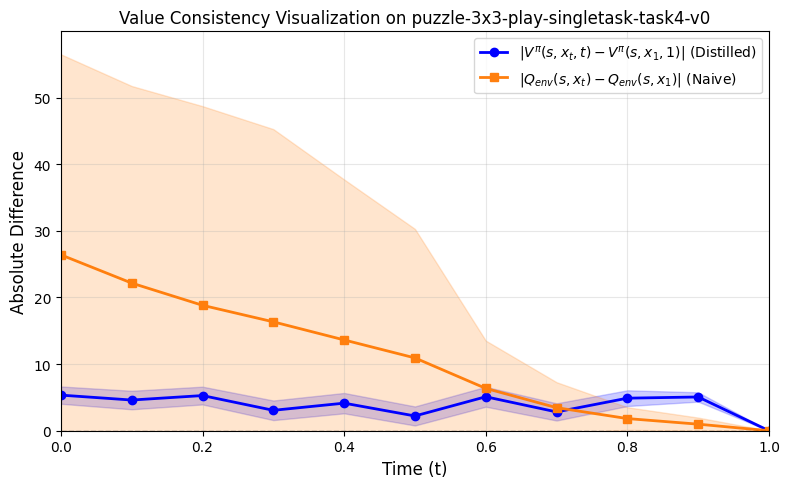

{'distilled_error_mean': array([5.343404 , 4.605626 , 5.2772903, 3.0635176, 4.137709 , 2.2139645,
       5.096759 , 2.8203716, 4.885507 , 5.0646505, 0.       ],
      dtype=float32), 'distilled_error_std': array([1.2960422, 1.3898032, 1.3332112, 1.4710495, 1.5272459, 1.4290402,
       1.4920238, 1.2931494, 1.1803687, 0.6997984, 0.       ],
      dtype=float32), 'naive_error_mean': array([26.396957 , 22.155245 , 18.823067 , 16.340225 , 13.624194 ,
       10.923895 ,  6.3523874,  3.4590034,  1.8228178,  0.9838476,
        0.       ], dtype=float32), 'naive_error_std': array([30.088104 , 29.575846 , 29.886389 , 28.920708 , 24.081078 ,
       19.358803 ,  7.167935 ,  3.8215814,  1.6962234,  0.984598 ,
        0.       ], dtype=float32)}


In [145]:

# ============================================================================
# Run the experiment with multiple states in batched mode
# ============================================================================

# Set the batch size (number of states in batch)
state_batch_size = 64

# Sample a batch of different states from success_states
sample_indices = np.random.choice(len(success_states), size=state_batch_size, replace=False)
sample_states = np.stack([success_states[i] for i in sample_indices], axis=0)   # shape: (batch, obs_dim)

print(f"Running Value Consistency Experiment (batched)")
print(f"  - Sampled state indices: {sample_indices}")
print(f"  - sample_states shape: {sample_states.shape}")
print(f"  - Flow steps: {agent.config['flow_steps']}")
print(f"  - Action dim: {agent.config['action_dim']}")
print(f"  - State batch size: {state_batch_size}")

# Run experiment in batched mode for all sampled states
# The experiment function may need slight adaptation if it does not natively support batching over initial states.
results_list = []
for i in tqdm(range(state_batch_size)):
    batched_results = run_value_consistency_experiment(
        agent,
        sample_states[i],
        flow_steps=10,
        seed=random.randint(0, 1000000),
        batch_size=32,
    )
    results_list.append(batched_results)

# Optionally, aggregate results over the batch (e.g., mean and std over batch of states)
def batch_stack_results(results_list, key):
    vals = np.stack([res[key] for res in results_list], axis=0)
    return vals.mean(axis=0), vals.std(axis=0)

mean_distilled, std_distilled = batch_stack_results(results_list, 'distilled_mean')
mean_naive, std_naive = batch_stack_results(results_list, 'naive_mean')

batch_results = results_list[0].copy()
batch_results['distilled_mean'] = mean_distilled
batch_results['distilled_std'] = std_distilled
batch_results['naive_mean'] = mean_naive
batch_results['naive_std'] = std_naive

# Plot results - Absolute Error to Ground Truth (batched average)
fig2, ax2, error_stats = plot_absolute_error(batch_results)
plt.title(f"Value Consistency Visualization on {env_name}")
plt.show()

print(error_stats)

## Value Consistency Visualization

In [2]:
def get_success_failure_idx(trajs):
    success_idx = []
    failure_idx = []
    for i in range(len(trajs)):
        if trajs[i]['reward'][-1] != -1:
            success_idx.append(i)
        else:
            failure_idx.append(i)

    return success_idx, failure_idx

def compute_q_values(agent, states, actions, batch_size=256):
    q_values = []
    num_data = states.shape[0]

    for batch_start in tqdm(range(0, num_data, batch_size)):
        batch_end = min(batch_start + batch_size, num_data)
        batch_states = states[batch_start:batch_end]
        batch_actions = actions[batch_start:batch_end]

        # Reshape for broadcasting, if needed
        batch_observations = batch_states.reshape(batch_states.shape[0], -1)
        batch_target_actions = batch_actions.reshape(batch_actions.shape[0], -1)

        qs = agent.network.select('critic')(batch_observations, batch_target_actions).mean(axis=0)
        q_values.extend(qs if np.ndim(qs) == 1 else qs.tolist())

    q_values = np.array(q_values)
    print(q_values.shape)

    return q_values

In [3]:
# ============================================================================
# Experiment 1: Value Consistency Plot (ODE Rollout Verification)
# ============================================================================
# Goal: Verify that the distilled value Q_inner(s, x_t, t) remains constant 
# along the flow trajectory, as predicted by the Transport Equation (dV/dt = 0).
#
# Expected behavior:
# - Q_phi(s, x_t, t) (Blue): Flat horizontal line aligned with V_GT
# - Q_outer(s, x_t) (Red): Erratic at t=0, converging to V_GT near t=1
# - V_GT (Black dotted): The ground truth value of the final clean action
# ============================================================================

import jax.numpy as jnp

def fourier_time_embed(t, embed_dim=64, max_freq=256.0):
    """
    Fourier positional embedding for time.
    Maps scalar t ∈ [0, 1] to a embed_dim-dimensional vector using sinusoidal features.
    
    Args:
        t: Time values of shape (batch, 1)
        embed_dim: Dimension of the embedding (must be even)
        max_freq: Maximum frequency for the Fourier features
        
    Returns:
        Embedding of shape (batch, embed_dim)
    """
    # Frequencies: log-spaced from 1 to max_freq
    half_dim = embed_dim // 2
    freqs = jnp.exp(jnp.linspace(0.0, jnp.log(max_freq), half_dim))
    # Apply frequencies to time: (batch, 1) * (half_dim,) -> (batch, half_dim)
    args = t * freqs[None, :]
    # Concatenate sin and cos: (batch, embed_dim)
    embedding = jnp.concatenate([jnp.sin(args), jnp.cos(args)], axis=-1)
    return embedding

def run_value_consistency_experiment(agent, state, flow_steps, seed=42, batch_size=256):
    """
    Run the value consistency experiment for a single state (BATCHED for speed).
    
    Args:
        agent: The trained fbrac_inner agent
        state: A single observation state (shape: obs_dim,)
        seed: Random seed for reproducibility
        batch_size: Number of noise samples to process in parallel
    
    Returns:
        Dictionary with timesteps, distilled/naive values (mean/std), and ground truth
    """
    rng = jax.random.PRNGKey(seed)
    # flow_steps = agent.config['flow_steps']
    action_dim = agent.config['action_dim']
    
    # Sample all initial noises at once: x_0 ~ N(0, I), shape: (batch_size, action_dim)
    rng, noise_rng = jax.random.split(rng)
    x_0 = jax.random.normal(noise_rng, (batch_size, action_dim))
    
    # Replicate state for batch: (batch_size, obs_dim)
    obs = jnp.tile(state[None, :], (batch_size, 1))
    
    # Initialize x_t with noise
    x_t = x_0  # Shape: (batch_size, action_dim)
    
    # Storage for values at each timestep: lists of (batch_size,) arrays
    all_distilled = []
    all_naive = []
    
    # Perform batched ODE rollout and compute values at each step
    for i in range(flow_steps + 1):
        t = i / flow_steps
        t_arr = jnp.full((batch_size, 1), t)  # Shape: (batch_size, 1)
        
        # --- Compute Distilled Value: Q_phi(s, x_t, t) ---
        # Using tc_critic (time-conditioned critic)
        if time_embed is not None:
            t_feature = fourier_time_embed(t_arr, embed_dim=time_embed)
            q_inner = agent.network.select('tc_critic')(obs, x_t, t_feature)
        else:
            q_inner = agent.network.select('tc_critic')(obs, x_t, t_arr)

        if q_inner.ndim > 1:
            q_inner = q_inner.mean(axis=0)  # Average over ensembles -> (batch_size,)
        all_distilled.append(np.array(q_inner))
        
        # --- Compute Naive Baseline: Q_outer(s, x_t) ---
        q_outer = agent.network.select('critic')(obs, x_t)
        if q_outer.ndim > 1:
            q_outer = q_outer.mean(axis=0)  # Average over ensembles -> (batch_size,)
        all_naive.append(np.array(q_outer))
        
        # --- Flow step (if not at terminal) ---
        if i < flow_steps:
            vels = agent.network.select('actor_bc_flow')(obs, x_t, t_arr)
            x_t = x_t + vels / flow_steps
    
    # --- Ground Truth: Q_outer(s, x_1) ---
    x_1 = jnp.clip(x_t, -1, 1)  # Final clean actions: (batch_size, action_dim)
    q_gt = agent.network.select('critic')(obs, x_1)

    t_arr = jnp.full((batch_size, 1), 1.)
    if time_embed is not None:
        t_arr = fourier_time_embed(t_arr, embed_dim=time_embed)
        
    q_inner_gt = agent.network.select('tc_critic')(obs, x_1, t_arr)
    if q_gt.ndim > 1:
        q_gt = q_gt.mean(axis=0)  # -> (batch_size,)
        q_inner_gt = q_inner_gt.mean(axis=0)
    all_gt = np.array(q_gt)
    all_inner_gt = np.array(q_inner_gt)
    
    # Convert to arrays: (flow_steps+1, batch_size)
    all_distilled = np.array(all_distilled)  # (flow_steps+1, batch_size)
    all_naive = np.array(all_naive)          # (flow_steps+1, batch_size)
    
    # Compute statistics across batch dimension
    timesteps = np.array([i / flow_steps for i in range(flow_steps + 1)])
    distilled_mean = np.mean(all_distilled, axis=1)  # (flow_steps+1,)
    distilled_std = np.std(all_distilled, axis=1)
    naive_mean = np.mean(all_naive, axis=1)
    naive_std = np.std(all_naive, axis=1)
    gt_mean = np.mean(all_gt)
    gt_std = np.std(all_gt)
    inner_gt_mean = np.mean(all_inner_gt)
    inner_gt_std = np.std(all_inner_gt)
    
    return {
        'timesteps': timesteps,
        'distilled_mean': distilled_mean,
        'distilled_std': distilled_std,
        'naive_mean': naive_mean,
        'naive_std': naive_std,
        'gt_mean': gt_mean,
        'gt_std': gt_std,
        'inner_gt_mean': inner_gt_mean,
        'inner_gt_std': inner_gt_std,
        'all_distilled': all_distilled.T,  # (batch_size, flow_steps+1) for compatibility
        'all_naive': all_naive.T,
        'all_gt': all_gt,
        'all_inner_gt': all_inner_gt,
    }


def plot_value_consistency(results, title="Value Consistency Along ODE Trajectory"):
    """
    Plot the value consistency experiment results.
    """
    fig, ax = plt.subplots(figsize=(10, 6))
    
    timesteps = results['timesteps']
    
    # Plot distilled value Q_phi(s, x_t, t) - should be flat
    ax.plot(timesteps, results['distilled_mean'], 'b-', linewidth=2, 
            label=r'$Q_\phi(s, x_t, t)$ (Distilled Inner Critic)')
    ax.fill_between(timesteps, 
                    results['distilled_mean'] - results['distilled_std'],
                    results['distilled_mean'] + results['distilled_std'],
                    alpha=0.2, color='blue')
    
    # Plot naive baseline Q_outer(s, x_t) - should be erratic
    ax.plot(timesteps, results['naive_mean'], 'r-', linewidth=2,
            label=r'$Q_{outer}(s, x_t)$ (Naive Baseline)')
    ax.fill_between(timesteps,
                    results['naive_mean'] - results['naive_std'],
                    results['naive_mean'] + results['naive_std'],
                    alpha=0.2, color='red')
    
    # Plot ground truth V_GT = Q_outer(s, x_1)
    ax.axhline(y=results['gt_mean'], color='black', linestyle='--', linewidth=2,
               label=r'$V_{GT} = Q_{outer}(s, x_1)$ (Ground Truth)')
    ax.axhspan(results['gt_mean'] - results['gt_std'], 
               results['gt_mean'] + results['gt_std'],
               alpha=0.1, color='gray')

    # Plot inner ground truth
    ax.axhline(y=results['inner_gt_mean'], color='green', linestyle='--', linewidth=2,
               label=r'$V_{GT}^{\mathrm{inner}} = V_{\mathrm{inner}}(s, x_1, 1)$ (Inner Ground Truth)')
    ax.axhspan(results['inner_gt_mean'] - results['inner_gt_std'],
               results['inner_gt_mean'] + results['inner_gt_std'],
               alpha=0.1, color='green')

    
    ax.set_xlabel('Timestep $t$', fontsize=12)
    ax.set_ylabel('Value Estimate', fontsize=12)
    ax.set_title(title, fontsize=14)
    ax.legend(loc='best', fontsize=10)
    ax.grid(True, alpha=0.3)
    ax.set_xlim([0, 1])
    
    plt.tight_layout()
    return fig, ax


def run_value_consistency_experiment_vectorized(agent, states, flow_steps, seed=42, noise_batch_size=32):
    """
    Vectorized version that processes ALL states in parallel.
    
    Args:
        agent: The trained fbrac_inner agent
        states: Array of states (num_states, obs_dim)
        seed: Random seed for reproducibility
        noise_batch_size: Number of noise samples per state
    
    Returns:
        List of dictionaries (one per state) with same structure as original function
    """
    rng = jax.random.PRNGKey(seed)
    action_dim = agent.config['action_dim']
    num_states = states.shape[0]
    obs_dim = states.shape[1]
    
    # Sample all initial noises for all states: (num_states, noise_batch_size, action_dim)
    rng, noise_rng = jax.random.split(rng)
    noise_keys = jax.random.split(noise_rng, num_states)
    x_0 = jax.vmap(lambda k: jax.random.normal(k, (noise_batch_size, action_dim)))(noise_keys)
    # x_0 shape: (num_states, noise_batch_size, action_dim)
    
    # Expand states: (num_states, 1, obs_dim) -> (num_states, noise_batch_size, obs_dim)
    obs = jnp.tile(states[:, None, :], (1, noise_batch_size, 1))
    
    # Initialize x_t with noise
    x_t = x_0  # Shape: (num_states, noise_batch_size, action_dim)
    
    # Storage for values at each timestep: (num_states, flow_steps+1, noise_batch_size)
    all_distilled = []
    all_naive = []
    
    # Perform batched ODE rollout and compute values at each step
    for i in range(flow_steps + 1):
        t = i / flow_steps
        t_arr = jnp.full((num_states, noise_batch_size, 1), t)
        
        # Reshape for network calls: flatten state and noise dimensions
        # (num_states * noise_batch_size, obs_dim) and (num_states * noise_batch_size, action_dim)
        obs_flat = obs.reshape(-1, obs_dim)
        x_t_flat = x_t.reshape(-1, action_dim)
        t_arr_flat = t_arr.reshape(-1, 1)
        
        # --- Compute Distilled Value: Q_phi(s, x_t, t) ---
        if time_embed is not None:
            t_feature = fourier_time_embed(t_arr_flat, embed_dim=time_embed)
            q_inner_flat = agent.network.select('tc_critic')(obs_flat, x_t_flat, t_feature)
        else:
            q_inner_flat = agent.network.select('tc_critic')(obs_flat, x_t_flat, t_arr_flat)
        
        if q_inner_flat.ndim > 1:
            q_inner_flat = q_inner_flat.mean(axis=0)  # Average over ensembles
        
        # Reshape back: (num_states, noise_batch_size)
        q_inner = q_inner_flat.reshape(num_states, noise_batch_size)
        all_distilled.append(q_inner)
        
        # --- Compute Naive Baseline: Q_outer(s, x_t) ---
        q_outer_flat = agent.network.select('critic')(obs_flat, x_t_flat)
        if q_outer_flat.ndim > 1:
            q_outer_flat = q_outer_flat.mean(axis=0)
        q_outer = q_outer_flat.reshape(num_states, noise_batch_size)
        all_naive.append(q_outer)
        
        # --- Flow step (if not at terminal) ---
        if i < flow_steps:
            vels_flat = agent.network.select('actor_bc_flow')(obs_flat, x_t_flat, t_arr_flat)
            vels = vels_flat.reshape(num_states, noise_batch_size, action_dim)
            x_t = x_t + vels / flow_steps
    
    # --- Ground Truth: Q_outer(s, x_1) ---
    x_1 = jnp.clip(x_t, -1, 1)  # (num_states, noise_batch_size, action_dim)
    obs_flat = obs.reshape(-1, obs_dim)
    x_1_flat = x_1.reshape(-1, action_dim)
    q_gt_flat = agent.network.select('critic')(obs_flat, x_1_flat)
    if q_gt_flat.ndim > 1:
        q_gt_flat = q_gt_flat.mean(axis=0)
    q_gt = q_gt_flat.reshape(num_states, noise_batch_size)
    
    t_arr_flat = jnp.full((num_states * noise_batch_size, 1), 1.)
    if time_embed is not None:
        t_arr_flat = fourier_time_embed(t_arr_flat, embed_dim=time_embed)
    q_inner_gt_flat = agent.network.select('tc_critic')(obs_flat, x_1_flat, t_arr_flat)
    if q_inner_gt_flat.ndim > 1:
        q_inner_gt_flat = q_inner_gt_flat.mean(axis=0)
    q_inner_gt = q_inner_gt_flat.reshape(num_states, noise_batch_size)
    
    # Convert to arrays and compute statistics per state
    all_distilled = np.array(all_distilled)  # (flow_steps+1, num_states, noise_batch_size)
    all_naive = np.array(all_naive)  # (flow_steps+1, num_states, noise_batch_size)
    all_distilled = np.transpose(all_distilled, (1, 0, 2))  # (num_states, flow_steps+1, noise_batch_size)
    all_naive = np.transpose(all_naive, (1, 0, 2))  # (num_states, flow_steps+1, noise_batch_size)
    
    timesteps = np.array([i / flow_steps for i in range(flow_steps + 1)])
    
    # Create results list (one dict per state, matching original format)
    results_list = []
    for state_idx in range(num_states):
        distilled_mean = np.mean(all_distilled[state_idx], axis=1)  # (flow_steps+1,)
        distilled_std = np.std(all_distilled[state_idx], axis=1)
        naive_mean = np.mean(all_naive[state_idx], axis=1)
        naive_std = np.std(all_naive[state_idx], axis=1)
        gt_mean = np.mean(q_gt[state_idx])
        gt_std = np.std(q_gt[state_idx])
        inner_gt_mean = np.mean(q_inner_gt[state_idx])
        inner_gt_std = np.std(q_inner_gt[state_idx])
        
        results_list.append({
            'timesteps': timesteps,
            'distilled_mean': distilled_mean,
            'distilled_std': distilled_std,
            'naive_mean': naive_mean,
            'naive_std': naive_std,
            'gt_mean': gt_mean,
            'gt_std': gt_std,
            'inner_gt_mean': inner_gt_mean,
            'inner_gt_std': inner_gt_std,
            'all_distilled': all_distilled[state_idx].T,  # (noise_batch_size, flow_steps+1)
            'all_naive': all_naive[state_idx].T,
            'all_gt': q_gt[state_idx],
            'all_inner_gt': q_inner_gt[state_idx],
        })
    
    return results_list


def plot_absolute_error(results, title="Absolute Error to Ground Truth"):
    """
    Plot the absolute error |V - V_GT| for both distilled and naive baseline.
    For the distilled/inner critic, use all_inner_gt as ground truth.
    """
    fig, ax = plt.subplots(figsize=(8, 5))
    
    timesteps = results['timesteps']
    gt_mean = results['gt_mean']
    
    # Compute absolute errors for each sample, then get mean/std
    # all_distilled: (batch_size, flow_steps+1), all_gt: (batch_size,)
    all_distilled = results['all_distilled']  # (batch_size, flow_steps+1)
    all_naive = results['all_naive']          # (batch_size, flow_steps+1)
    all_gt = results['all_gt']                # (batch_size,)
    all_inner_gt = results['all_inner_gt']    # (batch_size,)

    # For distilled, use all_inner_gt as the ground truth
    distilled_errors = np.abs(all_distilled - all_inner_gt[:, None])  # (batch_size, flow_steps+1)
    # For naive, use original ground truth all_gt
    naive_errors = np.abs(all_naive - all_gt[:, None])                # (batch_size, flow_steps+1)
    
    # Compute mean and std across batch
    distilled_error_mean = np.mean(distilled_errors, axis=0)  # (flow_steps+1,)
    distilled_error_std = np.std(distilled_errors, axis=0)
    naive_error_mean = np.mean(naive_errors, axis=0)
    naive_error_std = np.std(naive_errors, axis=0)
    
    # Plot distilled error
    ax.plot(timesteps, distilled_error_mean, 'b-', linewidth=2, marker='o',
            label=r'$|V^\pi(s, x_t, t) - V^\pi(s, x_1, 1)|$ (Distilled)')
    ax.fill_between(timesteps,
                    distilled_error_mean - distilled_error_std,
                    distilled_error_mean + distilled_error_std,
                    alpha=0.2, color='blue')
    
    # Plot naive error
    ax.plot(timesteps, naive_error_mean, linewidth=2, marker='s',
            color='tab:orange',
            label=r'$|Q_{env}(s, x_t) - Q_{env}(s, x_1)|$ (Naive)')
    ax.fill_between(timesteps,
                    naive_error_mean - naive_error_std,
                    naive_error_mean + naive_error_std,
                    alpha=0.2, color='tab:orange')
    
    # Add zero line for reference
    ax.axhline(y=0, color='black', linestyle='--', linewidth=1, alpha=0.5)
    
    ax.set_xlabel('Time (t)', fontsize=12)
    ax.set_ylabel('Absolute Difference', fontsize=12)
    ax.set_title(title, fontsize=14)
    ax.legend(loc='best', fontsize=10)
    ax.grid(True, alpha=0.3)
    ax.set_xlim([0, 1])
    ax.set_ylim(bottom=0)  # Error is always non-negative
    plt.grid(True)
    
    plt.tight_layout()
    return fig, ax, {
        'distilled_error_mean': distilled_error_mean,
        'distilled_error_std': distilled_error_std,
        'naive_error_mean': naive_error_mean,
        'naive_error_std': naive_error_std,
    }

In [4]:
task_config={
    "Antmaze-Large": {
        'env_name': f"antmaze-large-navigate-singletask-task1-v0",
        'alpha': 0.5,
        'q_agg': 'mean',
        'discount': 0.99,
        'use_residual': False,
        'layer_width': 512,
    },
    "Antmaze-Giant": {
        'env_name': f"antmaze-giant-navigate-singletask-task1-v0",
        'alpha': 0.5,
        'q_agg': 'min',
        'discount': 0.995,
        'use_residual': False,
        'layer_width': 512,
    },
    "Humanoidmaze-Medium": {
        'env_name': f"humanoidmaze-medium-navigate-singletask-task1-v0",
        'alpha': 2,
        'q_agg': 'mean',
        'discount': 0.995,
        'use_residual': False,
        'layer_width': 512,
    },
    "Humanoidmaze-Large": {
        'env_name': f"humanoidmaze-large-navigate-singletask-task1-v0",
        'alpha': 2,
        'q_agg': 'mean',
        'discount': 0.995,
        'use_residual': False,
        'layer_width': 512,
    },
    "Antsoccer": {
        'env_name': f"antsoccer-arena-navigate-singletask-task4-v0",
        'alpha': 1,
        'q_agg': 'mean',
        'discount': 0.995,
        'use_residual': False,
        'layer_width': 512,
    },
    "Cube-Single": {
        'env_name': f"cube-single-play-singletask-task2-v0",
        'alpha': 10,
        'q_agg': 'mean',
        'discount': 0.99,
        'use_residual': False,
        'layer_width': 256,
    },
    "Cube-Double": {
        'env_name': f"cube-double-play-singletask-task2-v0",
        'alpha': 5,
        'q_agg': 'mean',
        'discount': 0.99,
        'use_residual': False,
        'layer_width': 256,
    },
    "Scene": {
        'env_name': f"scene-play-singletask-task2-v0",
        'alpha': 10,
        'q_agg': 'mean',
        'discount': 0.99,
        'use_residual': False,
        'layer_width': 256,
    },
    "Puzzle-3x3": {
        'env_name': f"puzzle-3x3-play-singletask-task4-v0",
        'alpha': 50,
        'q_agg': 'min',
        'discount': 0.99,
        'use_residual': False,
        'layer_width': 256,
    },
    "Puzzle-4x4": {
        'env_name': f"puzzle-4x4-play-singletask-task4-v0",
        'alpha': 50,
        'q_agg': 'min',
        'discount': 0.99,
        'use_residual': False,
        'layer_width': 256,
    },
}

eval_results = {}

seed_range = range(8)  # For seeds 0..7

for task_name in task_config:
    task_info = task_config[task_name]
    env_name = task_info['env_name']

    all_seed_results = []

    for seed in seed_range:
        buffer_size = 2000000

        # Training hyperparameters (from run_fbrac_inner.sh)
        alpha = task_info['alpha']
        flow_steps = 10
        q_agg = task_info['q_agg']
        discount = task_info['discount']
        batch_size = 256
        layer_norm = True
        actor_layer_norm = False
        offline_steps = 1000000

        use_residual=task_info['use_residual']
        layer_width=task_info['layer_width']
        time_embed=16
        actor_loss_type='grad'

        # ============================================================================
        # CRITICAL FOR DETERMINISM: Set PYTHONHASHSEED (matching guidance_evaluation.py)
        # ============================================================================
        os.environ['PYTHONHASHSEED'] = str(seed)

        # Build experiment name and path (following run_fbrac_inner.sh pattern)
        if time_embed is None:
            exp_name = f"{env_name}_alpha{alpha}-flow{flow_steps}-qagg{q_agg}-discount{discount}___sd{seed:03d}"
        else:
            exp_name = f"{env_name}_alpha{alpha}-flow{flow_steps}-qagg{q_agg}-discount{discount}_time_embed{time_embed}__sd{seed:03d}"
        
        base_dir = "fourier_ablation"
        run_group = env_name
        agent_path = f"{base_dir}/fbrac_vd/{run_group}/{exp_name}"
        restore_epoch = offline_steps

        # Make environment and datasets (BEFORE seeding - matching guidance_evaluation.py order)
        env, eval_env, train_dataset, val_dataset = make_env_and_datasets(env_name, frame_stack=None)
        train_dataset = Dataset.create(**train_dataset)
        train_dataset = ReplayBuffer.create_from_initial_dataset(
            dict(train_dataset), size=max(buffer_size, train_dataset.size + 1)
        )

        # ============================================================================
        # Initialize random seeds AFTER environment creation (matching guidance_evaluation.py)
        # ============================================================================
        # random.seed(seed)
        # np.random.seed(seed)
        master_key = jax.random.PRNGKey(int(seed))

        # Seed environment action space for determinism
        if hasattr(eval_env, 'action_space'):
            eval_env.action_space.seed(seed)

        example_batch = train_dataset.sample(1)

        # Load agent config (following run_fbrac_inner.sh pattern)
        import importlib.util
        agent_config_path = "agents/fbrac_vd.py"
        spec = importlib.util.spec_from_file_location("agent_config", agent_config_path)
        agent_config_module = importlib.util.module_from_spec(spec)
        spec.loader.exec_module(agent_config_module)
        agent_config = agent_config_module.get_config()

        # Set hyperparameters in config (following run_fbrac_inner.sh pattern)
        agent_config.alpha = alpha
        agent_config.flow_steps = flow_steps
        agent_config.q_agg = q_agg
        agent_config.discount = discount
        agent_config.batch_size = batch_size
        agent_config.layer_norm = layer_norm
        agent_config.actor_layer_norm = actor_layer_norm
        agent_config.reward_scale = 1.0
        agent_config.use_time_decay = False
        agent_config.use_time_penalty=False
        agent_config.use_time_embed=True
        agent_config.time_embed_dim=time_embed
        agent_config.normalize_q_loss = False
        agent_config.value_hidden_dims = (layer_width,layer_width,layer_width,layer_width)
        agent_config.actor_loss_type=actor_loss_type
        agent_config.use_residual=use_residual
        agent_config.num_ensembles=2

        # Create agent (following guidance_evaluation.py pattern)
        agent_class = agents[agent_config['agent_name']]
        agent = agent_class.create(
            seed,
            example_batch['observations'],
            example_batch['actions'],
            agent_config,
        )

        # Restore agent (following guidance_evaluation.py pattern)
        if agent_path and restore_epoch:
            agent = restore_agent(agent, agent_path, restore_epoch)
            print(f"Agent restored from {agent_path} at epoch {restore_epoch}")

        print(f"Env: {env_name} Seed: {seed}")

        # Evaluation (following main.py pattern)
        random.seed(seed)
        np.random.seed(seed)
        os.environ['PYTHONHASHSEED'] = str(seed)
        eval_key = jax.random.PRNGKey(int(seed))

        eval_episodes = 10

        # Evaluate agent (matching main.py lines 202-210)
        stats, trajs, renders = evaluate(
            agent=agent,
            env=eval_env,
            config=agent_config,
            num_eval_episodes=eval_episodes,
            num_video_episodes=0,
            video_frame_skip=3,
            compute_eval_critic_loss=False,
            key=eval_key,
        )

        print(f"Evaluation results:")
        for k, v in stats.items():
            print(f"  {k}: {v}")

        success_idx, failure_idx = get_success_failure_idx(trajs)

        try:
            success_states = np.concatenate([np.array(x['observation']) for x in np.array(trajs)], axis=0)
            success_actions = np.concatenate([np.array(x['action']) for x in np.array(trajs)], axis=0)
        except:
            success_states = np.concatenate([np.array(x['observation']) for x in np.array(trajs)[failure_idx]], axis=0)
            success_actions = np.concatenate([np.array(x['action']) for x in np.array(trajs)[failure_idx]], axis=0)

        # Set the batch size (number of states in batch)
        state_batch_size = min(256, len(success_states))

        # Sample a batch of different states from success_states
        sample_indices = np.random.choice(len(success_states), size=state_batch_size, replace=False)
        sample_states = np.stack([success_states[i] for i in sample_indices], axis=0)   # shape: (batch, obs_dim)

        print(f"Running Value Consistency Experiment (vectorized)")
        print(f"  - Sampled state indices: {sample_indices}")
        print(f"  - sample_states shape: {sample_states.shape}")
        print(f"  - Flow steps: {agent.config['flow_steps']}")
        print(f"  - Action dim: {agent.config['action_dim']}")
        print(f"  - State batch size: {state_batch_size}")

        # Run experiment in vectorized mode - processes ALL states in parallel
        results_list = run_value_consistency_experiment_vectorized(
            agent,
            sample_states,
            flow_steps=10,
            seed=random.randint(0, 1000000),
            noise_batch_size=32,  # Number of noise samples per state
        )

        # Optionally, aggregate results over the batch (e.g., mean and std over batch of states)
        def batch_stack_results(results_list, key):
            vals = np.stack([res[key] for res in results_list], axis=0)
            return vals.mean(axis=0), vals.std(axis=0)

        mean_distilled, std_distilled = batch_stack_results(results_list, 'distilled_mean')
        mean_naive, std_naive = batch_stack_results(results_list, 'naive_mean')

        batch_results = results_list[0].copy()
        batch_results['distilled_mean'] = mean_distilled
        batch_results['distilled_std'] = std_distilled
        batch_results['naive_mean'] = mean_naive
        batch_results['naive_std'] = std_naive
        batch_results['timesteps'] = results_list[0]['timesteps']
        batch_results['all_distilled'] = results_list[0]['all_distilled']
        batch_results['all_naive'] = results_list[0]['all_naive']
        batch_results['all_gt'] = results_list[0]['all_gt']
        batch_results['all_inner_gt'] = results_list[0]['all_inner_gt']

        all_seed_results.append(batch_results)

    # Now, aggregate across seeds:
    # For all seeds: their arrays are (same shape), average across a new axis 0, compute mean and std
    # We'll keep results in same format, but the means/stds now reflect the variation across seeds (after already averaging over state batch)
    seed_distilled_means = np.stack([r['distilled_mean'] for r in all_seed_results], axis=0)
    seed_distilled_stds = np.stack([r['distilled_std'] for r in all_seed_results], axis=0)
    seed_naive_means = np.stack([r['naive_mean'] for r in all_seed_results], axis=0)
    seed_naive_stds = np.stack([r['naive_std'] for r in all_seed_results], axis=0)
    # These are for plotting mean+/-std over seeds

    agg_results = dict(
        timesteps = all_seed_results[0]['timesteps'],
        distilled_mean = seed_distilled_means.mean(axis=0),
        distilled_std = seed_distilled_means.std(axis=0),
        naive_mean = seed_naive_means.mean(axis=0),
        naive_std = seed_naive_means.std(axis=0),
        all_distilled = all_seed_results[0]['all_distilled'],
        all_naive = all_seed_results[0]['all_naive'],
        all_gt = all_seed_results[0]['all_gt'],
        all_inner_gt = all_seed_results[0]['all_inner_gt'],
    )

    eval_results[task_name] = agg_results

Restored from fourier_ablation/fbrac_vd/antmaze-large-navigate-singletask-task1-v0/antmaze-large-navigate-singletask-task1-v0_alpha0.5-flow10-qaggmean-discount0.99_time_embed16__sd000/params_1000000.pkl
Agent restored from fourier_ablation/fbrac_vd/antmaze-large-navigate-singletask-task1-v0/antmaze-large-navigate-singletask-task1-v0_alpha0.5-flow10-qaggmean-discount0.99_time_embed16__sd000 at epoch 1000000
Env: antmaze-large-navigate-singletask-task1-v0 Seed: 0


100%|██████████| 10/10 [00:05<00:00,  1.88it/s]


Evaluation results:
  xy: 29.901579264826104
  prev_qpos: 4.031945229937026
  prev_qvel: 0.006403310974461781
  qpos: 4.032700956079181
  qvel: 0.060606619505909495
  success: 1.0
  total.timesteps: 2199.9
  episode.final_reward: 0.0
  episode.return: -407.1
  episode.length: 408.1
  episode.duration: 0.5316288232803345
Running Value Consistency Experiment (vectorized)
  - Sampled state indices: [1478 3774 3476 1936 3271 1951  538 1798 1300 3943 3322  706 3818 3515
 1712 1587 3605 1871   87 1062 2644 2631 4024 3351 1330 3436 3194 3610
 2979  142 3791 2100  185 1427  666 3840  347 2770  598 3439 2992 1386
  566  536 1465 1005 2828 3936 2348   42  502 3174 2210  501 3227 1593
 2242 3092 2796 1934 1464 2990 3700 1826 3934 1572 1341 4012 3823   31
  615 2324 3588 3548 3836 1560 3828 2346 3597 1051  917 2853 3313  868
 3418 3263 3132 3746 2337 2740  567 3706 3210 2362 1422 1334 1733 1232
 2106 1501 1277  311 3381 1336 4078 1069 2618 2162   45 1698 3723  214
 1021 4074   33 3712 3702 2569  2

100%|██████████| 10/10 [00:06<00:00,  1.66it/s]


Evaluation results:
  xy: 29.805097743825183
  prev_qpos: 4.042719169516435
  prev_qvel: -0.046688508220753676
  qpos: 4.035075769954819
  qvel: -0.04940208298034616
  success: 1.0
  total.timesteps: 2638.9
  episode.final_reward: 0.0
  episode.return: -467.0
  episode.length: 468.0
  episode.duration: 0.6014963865280152
Running Value Consistency Experiment (vectorized)
  - Sampled state indices: [3727 3729 4021 2968 4495 4257 2637 1766 3494 2416 3183  808  169 2190
 3960 1915 4391 2555 1881 2490 1216 1427 3587 1023 2813 4376 4030 4630
  359 3218 2113 3788 1814 1011 1643 2849 3216 1043 1185 3848 1404 4031
 2719  636 1697  589 3624 2512 3677 1561 1063 4160   62  447 3789   21
 1660 1827 3358 3626 3124 4220 3327 3285 1690 2179  909 2000 1545 4406
 3120 2927  823  165 1929 2414  324 3669 1692  745 2528  965  769 2249
 4469  343 1907 2903 4556 1725 3225  325 1459 2850 2763 2864 4545 1475
 4631 2597 1852 3382 1548 1038  799 1458 2240 1395 4535 3016 4342  358
 2891 1802 1507   90 3787 3293 4

...

Evaluation results:
  prev_button_states: 0.21875
  button_states: 0.21875
  prev_qpos: -0.1374905565376857
  prev_qvel: -0.009857788032307675
  qpos: -0.13777092921979675
  qvel: -0.007308012446890579
  control: 34.91819925224832
  time: 22.494999999997606
  success: 0.2
  total.timesteps: 2590.4
  episode.final_reward: -3.5
  episode.return: -2063.9
  episode.length: 444.9
  episode.duration: 1.725481915473938
Running Value Consistency Experiment (vectorized)
  - Sampled state indices: [2550 3543 3680 4258 1333 2493  468 3083  417 2945 2066 3925 2819 3835
 1308 2899 4276  982 1848 2619 3403 2592 1402 2559  177 3646 2062 3308
  148 1228 1781    9  580 3435 4212 1614 2543 1431 2605 2002 3134 3730
 3802 2932 1545 1758 2594  240 1125 1570 3382 2165 1103  824 2455 3644
  667  948  603 2651 4016  321  563 4417 3463  317 2156 1566 1719 3453
  716 3391 2662 3584  457  944 2351 1550 2321 3352 3890 1519  278 1818
 3191  720 4021 2069 1734  850  714 1450 2317 1865  491  564  589  378
 3951 1944

100%|██████████| 10/10 [00:19<00:00,  1.92s/it]


Evaluation results:
  prev_button_states: 0.2125
  button_states: 0.225
  prev_qpos: -0.14055386874969594
  prev_qvel: -0.0003453743458738382
  qpos: -0.1402740897076095
  qvel: 0.0038119651938522217
  control: 34.889953690166784
  time: 23.649999999997767
  success: 0.2
  total.timesteps: 2589.6
  episode.final_reward: -3.4
  episode.return: -2109.2
  episode.length: 468.0
  episode.duration: 1.9184742212295531
Running Value Consistency Experiment (vectorized)
  - Sampled state indices: [3002 3435 2409  923  613  258 1723 2717 4564  558 1818  893 4310 2059
 2344 2502 1552 3651 4502 1316 3810  134  903 1437  396 1261 2270 1935
 1123 1993 4401 1820 2586 1171 1917 2102 1189 4213  207 1248 4525 2687
 2961  111 1664 4450 3062 2248  324  382 4475 1329  687 2590 4420 1988
 3321 1528 2779 4222 2636 4421 2939 2608 4580  804 4157   29 2689 2975
 1241  386 4267 3453  693 2217  159 3793 1231 4647 1335 1933 1704 2741
 2433 3167 4423 3498 3719 1571 4544 3648  909 3368 1546 2603 1402   52
 4520 1504

100%|██████████| 10/10 [00:19<00:00,  1.93s/it]


Evaluation results:
  prev_button_states: 0.16875
  button_states: 0.16875
  prev_qpos: -0.13881340550049126
  prev_qvel: -0.001964670664902699
  qpos: -0.13857135051538155
  qvel: 0.001675223672283715
  control: 35.17310920133576
  time: 24.60499999999724
  success: 0.1
  total.timesteps: 2698.4
  episode.final_reward: -2.7
  episode.return: -2283.4
  episode.length: 487.1
  episode.duration: 1.9296860456466676
Running Value Consistency Experiment (vectorized)
  - Sampled state indices: [2838 3041 3966 2306 1849 4115 3176 2609 3907  921 3328  145 3570 3487
 3380  474 4366 3859 1648 2603 1015 2208  517 2409 1344 4726 1464 4465
 3640 3675 1086  932 1137 2269 2147  318 4231 4731    4 4268 4254 1844
 2090 4052 4492 2557 4531 2626 1179  635 3742  884 3213  188 4193 2481
  981  569 1893 3762  511 3105 2462 2290 2079 1769 1153 2509 1696 3553
 3865 3457 1107 2194 2455 4023 4087   78  446 4357 4043 2813 3510 1625
 2602 2153 2252 1493 3148  194  615 4700 2496 2547 2775 1854 2512 3673
 1483 3918

In [7]:
eval_results.keys()

dict_keys(['Antmaze-Large', 'Antmaze-Giant', 'Humanoidmaze-Medium', 'Humanoidmaze-Large', 'Antsoccer', 'Cube-Single', 'Cube-Double', 'Scene', 'Puzzle-3x3', 'Puzzle-4x4'])

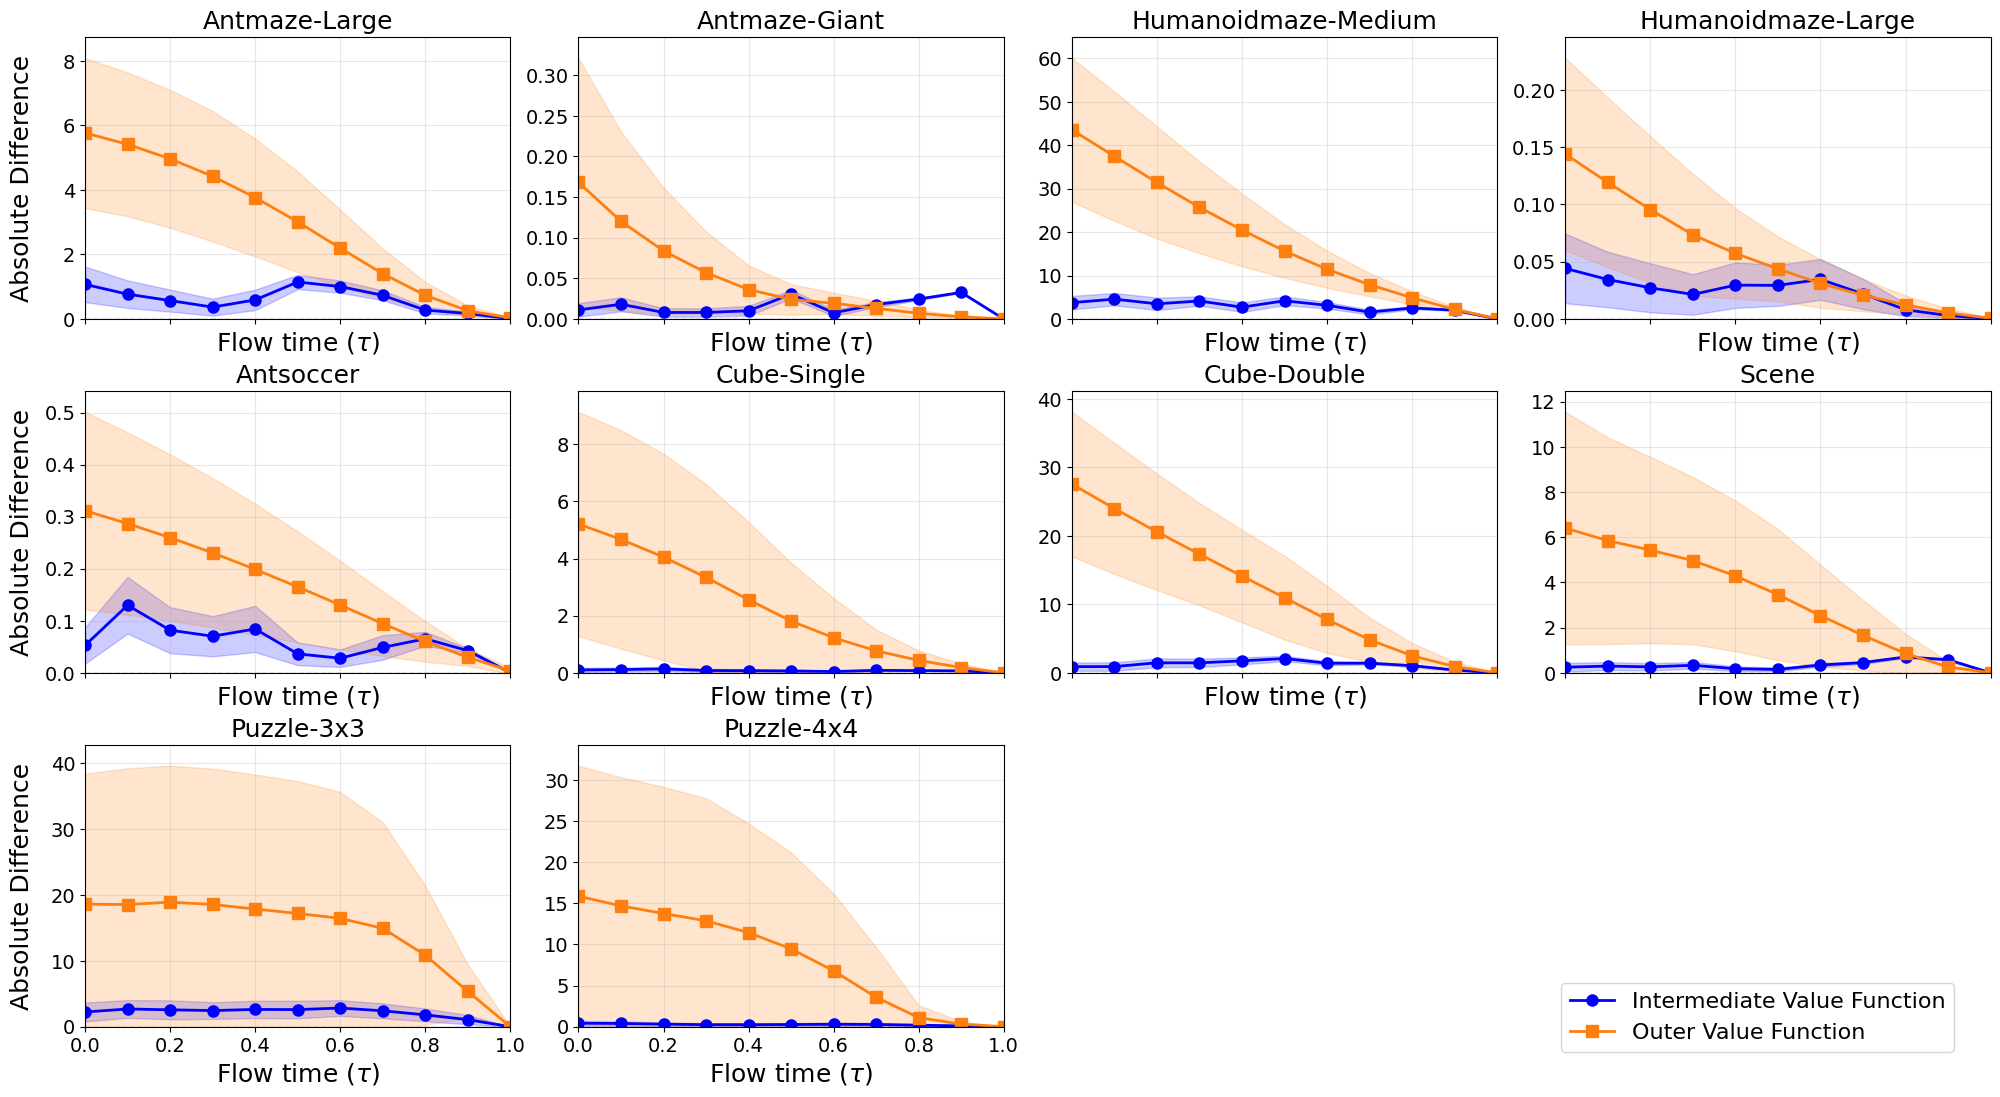

In [13]:
# Plot absolute errors for all tasks in eval_results in a 3x4 grid (10 tasks, 2 empty)
import matplotlib.pyplot as plt

n_tasks = len(eval_results)
ncols = 4
nrows = 3  # 10/4 = 2.5, so use 3 rows for 12 subplots (2 extra will be empty)
fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(ncols * 5, nrows * 4), sharex=True)

# Flatten axes for easier indexing
axes = axes.flatten()
plot_handles = []

marker_size = 8  # Increased marker size
label_fontsize = 18
title_fontsize = 18
tick_fontsize = 14
legend_fontsize = 16

# Optionally: Compute the y-limits for each subplot individually
for idx, (task_name, results) in enumerate(eval_results.items()):
    ax = axes[idx]
    timesteps = results['timesteps']

    # (batch_size, flow_steps+1)
    all_distilled = results['all_distilled']
    all_naive = results['all_naive']
    all_gt = results['all_gt']
    all_inner_gt = results['all_inner_gt']

    # Absolute errors
    distilled_errors = np.abs(all_distilled - all_inner_gt[:, None])
    naive_errors = np.abs(all_naive - all_gt[:, None])

    # Mean and std across batch
    distilled_error_mean = np.mean(distilled_errors, axis=0)
    distilled_error_std = np.std(distilled_errors, axis=0)
    naive_error_mean = np.mean(naive_errors, axis=0)
    naive_error_std = np.std(naive_errors, axis=0)

    # Plot distilled error (keep handle for legend only for first subplot)
    h_distilled, = ax.plot(
        timesteps, distilled_error_mean, 'b-', linewidth=2, marker='o',
        markersize=marker_size,
        label=r'Intermediate Value Function'
    )
    ax.fill_between(
        timesteps,
        distilled_error_mean - distilled_error_std,
        distilled_error_mean + distilled_error_std,
        alpha=0.2, color='blue'
    )

    # Plot naive error
    h_naive, = ax.plot(
        timesteps, naive_error_mean, linewidth=2, marker='s',
        color='tab:orange',
        markersize=marker_size,
        label=r'Outer Value Function'
    )
    ax.fill_between(
        timesteps,
        naive_error_mean - naive_error_std,
        naive_error_mean + naive_error_std,
        alpha=0.2, color='tab:orange'
    )

    if idx == 0:
        plot_handles = [h_distilled, h_naive]

    # Zero reference line
    ax.axhline(y=0, color='black', linestyle='--', linewidth=1, alpha=0.5)
    ax.set_xlabel(r'Flow time ($\tau$)', fontsize=label_fontsize)
    # Only set ylabel on leftmost column and align it
    if idx % ncols == 0:
        ax.set_ylabel('Absolute Difference', fontsize=label_fontsize, labelpad=22)
        ax.yaxis.set_label_coords(-0.12, 0.5)  # left-align y label (x, y) coords
    ax.set_title(task_name, fontsize=title_fontsize)
    ax.grid(True, alpha=0.3)
    ax.set_xlim([0, 1])
    ax.tick_params(axis='x', labelsize=tick_fontsize)
    ax.tick_params(axis='y', labelsize=tick_fontsize)

    # Set individual y-limits (start at 0, go slightly above max error with margin)
    max_y = max(
        (distilled_error_mean + distilled_error_std).max() if len(distilled_error_mean) > 0 else 0,
        (naive_error_mean + naive_error_std).max() if len(naive_error_mean) > 0 else 0,
    )
    ax.set_ylim(bottom=0, top=max_y * 1.08 if max_y > 0 else 1.0)
    # No per-plot legend

# Hide unused subplots (if any)
for idx in range(n_tasks, nrows * ncols):
    axes[idx].axis('off')

# One legend in the lower right subplot (last one, which is empty)
# Place the legend in the lower right empty subplot area
handles, labels = plot_handles, [h.get_label() for h in plot_handles]
fig.legend(
    handles, labels,
    loc='lower right',
    fontsize=legend_fontsize,
    frameon=True,
    bbox_to_anchor=(0.98, 0.11),
)

plt.tight_layout(rect=[0, 0, 1, 1])
plt.savefig('/mnt/nas/jaehyeok/fql/exp/value_error_plot_full.png')
plt.subplots_adjust(bottom=0.14)  # make space for the legend

# Output: fig, axes

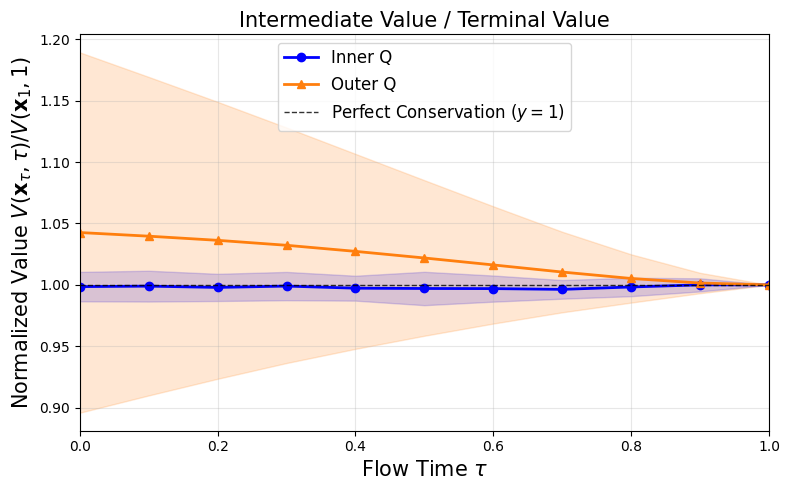

In [6]:
# Strategy 1 & 2: Plot Normalized Value Conservation Curves (Distilled vs. Naive Baseline)
# For each task, for every trajectory, plot V(x_tau, tau) divided by its own terminal value V(x_1, 1).
# Do this for both the distilled estimator and the naive baseline, and overlay both aggregated curves for comparison.

all_timesteps = None
all_task_normalized_distilled = []
all_task_normalized_naive = []

epsilon = 1e-6  # For safe division

for task_name, results in eval_results.items(): 
    # all_distilled: array shape (num_trajectories, num_timesteps)
    # all_naive: array shape (num_trajectories, num_timesteps)
    all_distilled = results['all_distilled']  # V_psi(x_tau, tau)
    all_naive = results.get('all_naive', None)  # Naive baseline: V_base(x_tau, tau)
    timesteps = results['timesteps']

    # Compute per-trajectory normalization against terminal value (last timestep)
    terminal_vals_distilled = all_distilled[:, -1]
    normalized_trajs_distilled = all_distilled / (terminal_vals_distilled[:, None] + epsilon)
    all_task_normalized_distilled.append(normalized_trajs_distilled)

    # Only plot naive baseline if present
    if all_naive is not None:
        terminal_vals_naive = all_naive[:, -1]
        normalized_trajs_naive = all_naive / (terminal_vals_naive[:, None] + epsilon)
        all_task_normalized_naive.append(normalized_trajs_naive)

    if all_timesteps is None:
        all_timesteps = timesteps

# Concatenate all trajectories across all tasks: (N_all_trajectories, timesteps)
all_normalized_distilled = np.concatenate(all_task_normalized_distilled, axis=0)
mean_curve_distilled = np.mean(all_normalized_distilled, axis=0)
std_curve_distilled = np.std(all_normalized_distilled, axis=0)

plt.figure(figsize=(8, 5))

# Distilled curve
plt.plot(
    all_timesteps, mean_curve_distilled, color='b', marker='o', linewidth=2,
    label=r'Inner Q'
)
plt.fill_between(
    all_timesteps, mean_curve_distilled - std_curve_distilled, mean_curve_distilled + std_curve_distilled,
    color='b', alpha=0.18, label=None
)

# Naive baseline curve (if info present)
if all_task_normalized_naive:
    all_normalized_naive = np.concatenate(all_task_normalized_naive, axis=0)
    mean_curve_naive = np.mean(all_normalized_naive, axis=0)
    std_curve_naive = np.std(all_normalized_naive, axis=0)
    plt.plot(
        all_timesteps, mean_curve_naive, color='tab:orange', marker='^', linewidth=2,
        label=r'Outer Q'
    )
    plt.fill_between(
        all_timesteps, mean_curve_naive - std_curve_naive, mean_curve_naive + std_curve_naive,
        color='tab:orange', alpha=0.18, label=None
    )

plt.axhline(1.0, color='black', linestyle='--', linewidth=1, alpha=0.8, label='Perfect Conservation ($y=1$)')
plt.xlabel(r'Flow Time $\tau$', fontsize=15)
plt.ylabel(r'Normalized Value $V(\mathbf{x}_\tau, \tau)/V(\mathbf{x}_1, 1)$', fontsize=15)
plt.title('Intermediate Value / Terminal Value', fontsize=15)
plt.grid(True, alpha=0.3)
plt.xlim([0, 1])

plt.legend(fontsize=12, frameon=True, loc='upper center')
plt.tight_layout()

# Output: plt.figure


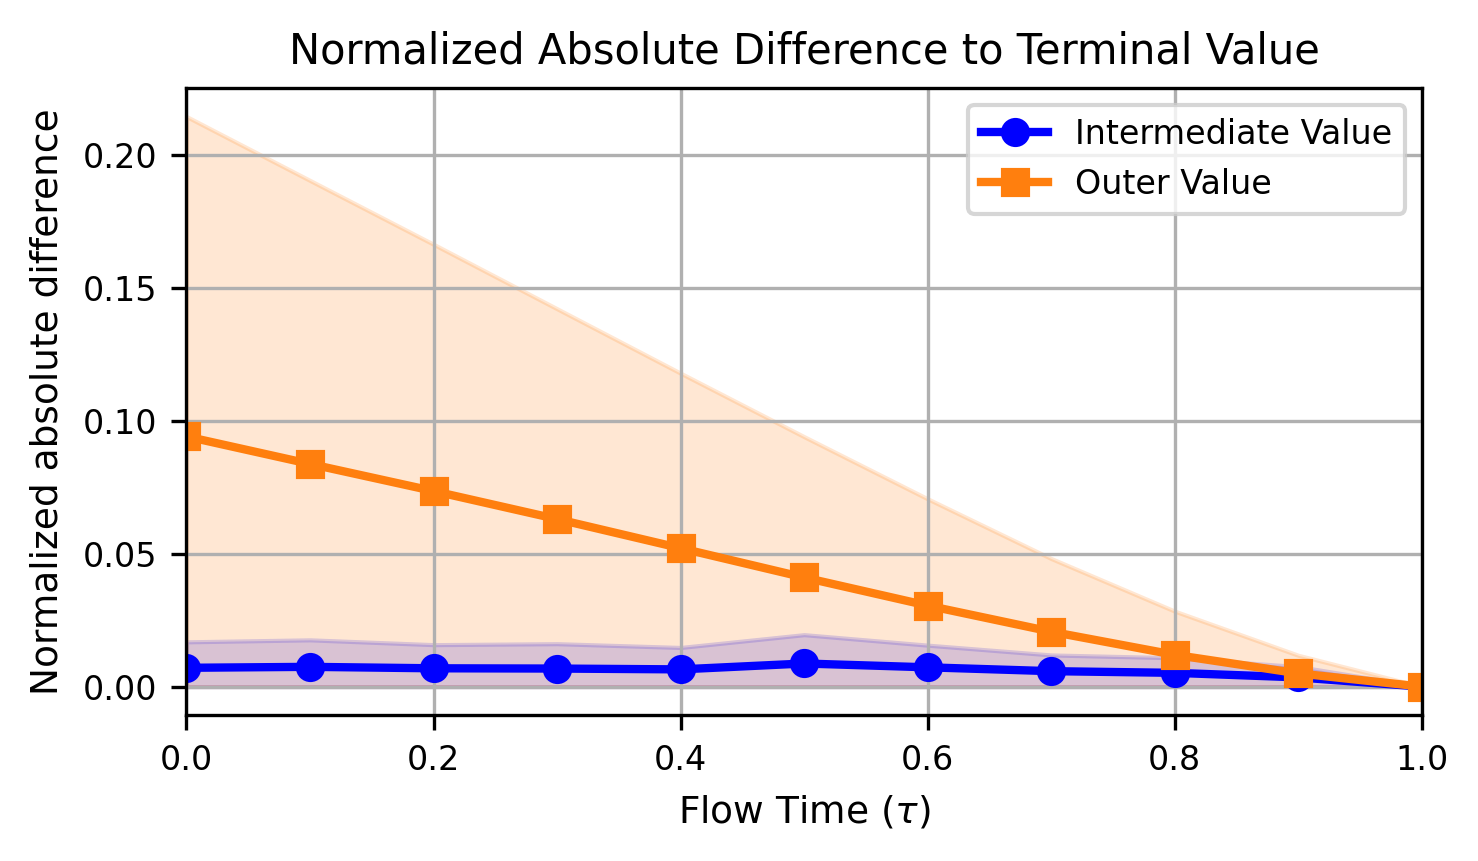

In [ ]:
all_timesteps = None
all_task_errors_distilled = []
all_task_errors_naive = []

epsilon = 1e-6  # Prevent division by zero

for task_name, results in eval_results.items(): 
    all_distilled = results['all_distilled']  # Shape: (N_traj, T)
    all_naive = results.get('all_naive', None)
    timesteps = results['timesteps']
    
    # --- Distilled (TVL) ---
    terminal_vals_distilled = all_distilled[:, -1] # V(x_1, 1)
    # Formula: | V_tau - V_1 | / ( |V_1| + eps )
    abs_diff_distilled = np.abs(all_distilled - terminal_vals_distilled[:, None])
    normalized_error_distilled = abs_diff_distilled / (np.abs(terminal_vals_distilled[:, None]) + epsilon)
    
    all_task_errors_distilled.append(normalized_error_distilled)

    # --- Naive Baseline ---
    if all_naive is not None:
        terminal_vals_naive = all_naive[:, -1]
        abs_diff_naive = np.abs(all_naive - terminal_vals_naive[:, None])
        normalized_error_naive = abs_diff_naive / (np.abs(terminal_vals_naive[:, None]) + epsilon)
        
        all_task_errors_naive.append(normalized_error_naive)

    if all_timesteps is None:
        all_timesteps = timesteps

# Concatenate and Average
all_errors_distilled = np.concatenate(all_task_errors_distilled, axis=0)
mean_error_distilled = np.mean(all_errors_distilled, axis=0)
std_error_distilled = np.std(all_errors_distilled, axis=0)

plt.figure(figsize=(5, 3), dpi=300)

marker_sz = 6
tick_label_size = 7

# Plot Distilled
plt.plot(
    all_timesteps, mean_error_distilled, color='b', marker='o', linewidth=2,
    label='Intermediate Value', markersize=marker_sz
)
plt.fill_between(
    all_timesteps, 
    np.maximum(0, mean_error_distilled - std_error_distilled), # Error can't be < 0
    mean_error_distilled + std_error_distilled,
    color='b', alpha=0.18
)

# Plot Naive
if all_task_errors_naive:
    all_errors_naive = np.concatenate(all_task_errors_naive, axis=0)
    mean_error_naive = np.mean(all_errors_naive, axis=0)
    std_error_naive = np.std(all_errors_naive, axis=0)
    
    plt.plot(
        all_timesteps, mean_error_naive, color='tab:orange', marker='s', linewidth=2,
        label='Outer Value', markersize=marker_sz
    )
    plt.fill_between(
        all_timesteps, 
        np.maximum(0, mean_error_naive - std_error_naive), 
        mean_error_naive + std_error_naive,
        color='tab:orange', alpha=0.18
    )

# Formatting
plt.xlabel(r'Flow Time ($\tau$)', fontsize=9)
plt.ylabel(r'Normalized Absolute Difference', fontsize=9)
plt.title('Normalized Absolute Difference to Terminal Value', fontsize=10)
plt.tight_layout()
plt.grid(True)
plt.xlim([0, 1])
# plt.yticks([0.0, 0.1, 0.2])

plt.legend(fontsize=8) # Legend usually moves to top-left for error plots

# Set tick label size
plt.gca().tick_params(axis='both', labelsize=8)

plt.savefig('/mnt/nas/jaehyeok/fql/exp/value_error_plot.png', dpi=300)
plt.show()

## Transported Value landscape over Flow

In [ ]:
task_config={
    "Antmaze-Large": {
        'env_name': f"antmaze-large-navigate-singletask-task1-v0",
        'alpha': 0.5,
        'q_agg': 'mean',
        'discount': 0.99,
        'use_residual': False,
        'layer_width': 512,
    },
    "Antmaze-Giant": {
        'env_name': f"antmaze-giant-navigate-singletask-task1-v0",
        'alpha': 0.5,
        'q_agg': 'min',
        'discount': 0.995,
        'use_residual': False,
        'layer_width': 512,
    },
    "Humanoidmaze-Medium": {
        'env_name': f"humanoidmaze-medium-navigate-singletask-task1-v0",
        'alpha': 2,
        'q_agg': 'mean',
        'discount': 0.995,
        'use_residual': False,
        'layer_width': 512,
    },
    "Humanoidmaze-Large": {
        'env_name': f"humanoidmaze-large-navigate-singletask-task1-v0",
        'alpha': 2,
        'q_agg': 'mean',
        'discount': 0.995,
        'use_residual': False,
        'layer_width': 512,
    },
    "Antsoccer": {
        'env_name': f"antsoccer-arena-navigate-singletask-task4-v0",
        'alpha': 1,
        'q_agg': 'mean',
        'discount': 0.995,
        'use_residual': False,
        'layer_width': 512,
    },
    "Cube-Single": {
        'env_name': f"cube-single-play-singletask-task2-v0",
        'alpha': 10,
        'q_agg': 'mean',
        'discount': 0.99,
        'use_residual': False,
        'layer_width': 256,
    },
    "Cube-Double": {
        'env_name': f"cube-double-play-singletask-task2-v0",
        'alpha': 5,
        'q_agg': 'mean',
        'discount': 0.99,
        'use_residual': False,
        'layer_width': 256,
    },
    "Scene": {
        'env_name': f"scene-play-singletask-task2-v0",
        'alpha': 10,
        'q_agg': 'mean',
        'discount': 0.99,
        'use_residual': False,
        'layer_width': 256,
    },
    "Puzzle-3x3": {
        'env_name': f"puzzle-3x3-play-singletask-task4-v0",
        'alpha': 50,
        'q_agg': 'min',
        'discount': 0.99,
        'use_residual': False,
        'layer_width': 256,
    },
    "Puzzle-4x4": {
        'env_name': f"puzzle-4x4-play-singletask-task4-v0",
        'alpha': 50,
        'q_agg': 'min',
        'discount': 0.99,
        'use_residual': False,
        'layer_width': 256,
    },
}


# Transported Value Landscape Visualization
eval_results = {}

seed_range = range(8)  # For seeds 0..7

for task_name in task_config:
    task_info = task_config[task_name]
    env_name = task_info['env_name']

    all_seed_results = []

    for seed in seed_range:
        buffer_size = 2000000

        # Training hyperparameters (from run_fbrac_inner.sh)
        alpha = task_info['alpha']
        flow_steps = 10
        q_agg = task_info['q_agg']
        discount = task_info['discount']
        batch_size = 256
        layer_norm = True
        actor_layer_norm = False
        offline_steps = 1000000

        use_residual=task_info['use_residual']
        layer_width=task_info['layer_width']
        time_embed=16
        actor_loss_type='grad'

        # ============================================================================
        # CRITICAL FOR DETERMINISM: Set PYTHONHASHSEED (matching guidance_evaluation.py)
        # ============================================================================
        os.environ['PYTHONHASHSEED'] = str(seed)

        # Build experiment name and path (following run_fbrac_inner.sh pattern)
        if time_embed is None:
            exp_name = f"{env_name}_alpha{alpha}-flow{flow_steps}-qagg{q_agg}-discount{discount}___sd{seed:03d}"
        else:
            exp_name = f"{env_name}_alpha{alpha}-flow{flow_steps}-qagg{q_agg}-discount{discount}_time_embed{time_embed}__sd{seed:03d}"
        if use_residual:
            base_dir = "residual_ablation"
        else:
            base_dir = "fourier_ablation"
        run_group = env_name
        agent_path = f"{base_dir}/fbrac_vd/{run_group}/{exp_name}"
        restore_epoch = offline_steps

        # Make environment and datasets (BEFORE seeding - matching guidance_evaluation.py order)
        env, eval_env, train_dataset, val_dataset = make_env_and_datasets(env_name, frame_stack=None)
        train_dataset = Dataset.create(**train_dataset)
        train_dataset = ReplayBuffer.create_from_initial_dataset(
            dict(train_dataset), size=max(buffer_size, train_dataset.size + 1)
        )

        # ============================================================================
        # Initialize random seeds AFTER environment creation (matching guidance_evaluation.py)
        # ============================================================================
        # random.seed(seed)
        # np.random.seed(seed)
        master_key = jax.random.PRNGKey(int(seed))

        # Seed environment action space for determinism
        if hasattr(eval_env, 'action_space'):
            eval_env.action_space.seed(seed)

        example_batch = train_dataset.sample(1)

        # Load agent config (following run_fbrac_inner.sh pattern)
        import importlib.util
        agent_config_path = "agents/fbrac_vd.py"
        spec = importlib.util.spec_from_file_location("agent_config", agent_config_path)
        agent_config_module = importlib.util.module_from_spec(spec)
        spec.loader.exec_module(agent_config_module)
        agent_config = agent_config_module.get_config()

        # Set hyperparameters in config (following run_fbrac_inner.sh pattern)
        agent_config.alpha = alpha
        agent_config.flow_steps = flow_steps
        agent_config.q_agg = q_agg
        agent_config.discount = discount
        agent_config.batch_size = batch_size
        agent_config.layer_norm = layer_norm
        agent_config.actor_layer_norm = actor_layer_norm
        agent_config.reward_scale = 1.0
        agent_config.use_time_decay = False
        agent_config.use_time_penalty=False
        agent_config.use_time_embed=True
        agent_config.time_embed_dim=time_embed
        agent_config.normalize_q_loss = False
        agent_config.value_hidden_dims = (layer_width,layer_width,layer_width,layer_width)
        agent_config.actor_loss_type=actor_loss_type
        agent_config.use_residual=use_residual
        agent_config.num_ensembles=2

        # Create agent (following guidance_evaluation.py pattern)
        agent_class = agents[agent_config['agent_name']]
        agent = agent_class.create(
            seed,
            example_batch['observations'],
            example_batch['actions'],
            agent_config,
        )

        # Restore agent (following guidance_evaluation.py pattern)
        if agent_path and restore_epoch:
            agent = restore_agent(agent, agent_path, restore_epoch)
            print(f"Agent restored from {agent_path} at epoch {restore_epoch}")

        print(f"Env: {env_name} Seed: {seed}")

        # Evaluation (following main.py pattern)
        random.seed(seed)
        np.random.seed(seed)
        os.environ['PYTHONHASHSEED'] = str(seed)
        eval_key = jax.random.PRNGKey(int(seed))

        eval_episodes = 10

        # Evaluate agent (matching main.py lines 202-210)
        stats, trajs, renders = evaluate(
            agent=agent,
            env=eval_env,
            config=agent_config,
            num_eval_episodes=eval_episodes,
            num_video_episodes=0,
            video_frame_skip=3,
            compute_eval_critic_loss=False,
            key=eval_key,
        )

        print(f"Evaluation results:")
        for k, v in stats.items():
            print(f"  {k}: {v}")

        success_idx, failure_idx = get_success_failure_idx(trajs)

        try:
            success_states = np.concatenate([np.array(x['observation']) for x in np.array(trajs)], axis=0)
            success_actions = np.concatenate([np.array(x['action']) for x in np.array(trajs)], axis=0)
        except:
            success_states = np.concatenate([np.array(x['observation']) for x in np.array(trajs)[failure_idx]], axis=0)
            success_actions = np.concatenate([np.array(x['action']) for x in np.array(trajs)[failure_idx]], axis=0)

        # Set the batch size (number of states in batch)
        state_batch_size = min(1000, len(success_states))

        # Sample a batch of different states from success_states
        sample_indices = np.random.choice(len(success_states), size=state_batch_size, replace=False)
        sample_states = np.stack([success_states[i] for i in sample_indices], axis=0)   # shape: (batch, obs_dim)

        print(f"Running Value Consistency Experiment (vectorized)")
        print(f"  - Sampled state indices: {sample_indices}")
        print(f"  - sample_states shape: {sample_states.shape}")
        print(f"  - Flow steps: {agent.config['flow_steps']}")
        print(f"  - Action dim: {agent.config['action_dim']}")
        print(f"  - State batch size: {state_batch_size}")

        # Run experiment in vectorized mode - processes ALL states in parallel
        results_list = run_value_consistency_experiment_vectorized(
            agent,
            sample_states,
            flow_steps=10,
            seed=random.randint(0, 1000000),
            noise_batch_size=64,  # Number of noise samples per state
        )

        # Optionally, aggregate results over the batch (e.g., mean and std over batch of states)
        def batch_stack_results(results_list, key):
            vals = np.stack([res[key] for res in results_list], axis=0)
            return vals.mean(axis=0), vals.std(axis=0)

        mean_distilled, std_distilled = batch_stack_results(results_list, 'distilled_mean')
        mean_naive, std_naive = batch_stack_results(results_list, 'naive_mean')

        batch_results = results_list[0].copy()
        batch_results['distilled_mean'] = mean_distilled
        batch_results['distilled_std'] = std_distilled
        batch_results['naive_mean'] = mean_naive
        batch_results['naive_std'] = std_naive
        batch_results['timesteps'] = results_list[0]['timesteps']
        batch_results['all_distilled'] = results_list[0]['all_distilled']
        batch_results['all_naive'] = results_list[0]['all_naive']
        batch_results['all_gt'] = results_list[0]['all_gt']
        batch_results['all_inner_gt'] = results_list[0]['all_inner_gt']

        all_seed_results.append(batch_results)

    # Now, aggregate across seeds:
    # For all seeds: their arrays are (same shape), average across a new axis 0, compute mean and std
    # We'll keep results in same format, but the means/stds now reflect the variation across seeds (after already averaging over state batch)
    seed_distilled_means = np.stack([r['distilled_mean'] for r in all_seed_results], axis=0)
    seed_distilled_stds = np.stack([r['distilled_std'] for r in all_seed_results], axis=0)
    seed_naive_means = np.stack([r['naive_mean'] for r in all_seed_results], axis=0)
    seed_naive_stds = np.stack([r['naive_std'] for r in all_seed_results], axis=0)
    # These are for plotting mean+/-std over seeds

    agg_results = dict(
        timesteps = all_seed_results[0]['timesteps'],
        distilled_mean = seed_distilled_means.mean(axis=0),
        distilled_std = seed_distilled_means.std(axis=0),
        naive_mean = seed_naive_means.mean(axis=0),
        naive_std = seed_naive_means.std(axis=0),
        all_distilled = all_seed_results[0]['all_distilled'],
        all_naive = all_seed_results[0]['all_naive'],
        all_gt = all_seed_results[0]['all_gt'],
        all_inner_gt = all_seed_results[0]['all_inner_gt'],
    )

    eval_results[task_name] = agg_results

In [239]:
# ============================================================================
# Simplified: Load Antmaze-Large agent, test critic, run 10 eval episodes,
# and sample 1 random state from success trajectories
# ============================================================================

# Configuration for Antmaze-Large
task_name = "Antmaze-Large"
task_config= {
    "Antmaze-Large": {
        'env_name': f"antmaze-large-navigate-singletask-task1-v0",
        'alpha': 0.5,
        'q_agg': 'mean',
        'discount': 0.99,
        'use_residual': False,
        'layer_width': 512,
    },
    "Antmaze-Giant": {
        'env_name': f"antmaze-giant-navigate-singletask-task1-v0",
        'alpha': 0.5,
        'q_agg': 'min',
        'discount': 0.995,
        'use_residual': False,
        'layer_width': 512,
    },
    "Humanoidmaze-Medium": {
        'env_name': f"humanoidmaze-medium-navigate-singletask-task1-v0",
        'alpha': 2,
        'q_agg': 'mean',
        'discount': 0.995,
        'use_residual': False,
        'layer_width': 512,
    },
    "Humanoidmaze-Large": {
        'env_name': f"humanoidmaze-large-navigate-singletask-task1-v0",
        'alpha': 2,
        'q_agg': 'mean',
        'discount': 0.995,
        'use_residual': False,
        'layer_width': 512,
    },
    "Antsoccer": {
        'env_name': f"antsoccer-arena-navigate-singletask-task4-v0",
        'alpha': 1,
        'q_agg': 'mean',
        'discount': 0.995,
        'use_residual': False,
        'layer_width': 512,
    },
    "Cube-Single": {
        'env_name': f"cube-single-play-singletask-task2-v0",
        'alpha': 10,
        'q_agg': 'mean',
        'discount': 0.99,
        'use_residual': False,
        'layer_width': 256,
    },
    "Cube-Double": {
        'env_name': f"cube-double-play-singletask-task2-v0",
        'alpha': 5,
        'q_agg': 'mean',
        'discount': 0.99,
        'use_residual': False,
        'layer_width': 256,
    },
    "Scene": {
        'env_name': f"scene-play-singletask-task2-v0",
        'alpha': 10,
        'q_agg': 'mean',
        'discount': 0.99,
        'use_residual': False,
        'layer_width': 256,
    },
    "Puzzle-3x3": {
        'env_name': f"puzzle-3x3-play-singletask-task4-v0",
        'alpha': 50,
        'q_agg': 'min',
        'discount': 0.99,
        'use_residual': False,
        'layer_width': 256,
    },
    "Puzzle-4x4": {
        'env_name': f"puzzle-4x4-play-singletask-task4-v0",
        'alpha': 50,
        'q_agg': 'min',
        'discount': 0.99,
        'use_residual': False,
        'layer_width': 256,
    },
}
task_info = task_config[task_name]

seed = 0
buffer_size = 2000000
eval_episodes = 10

# Training hyperparameters
alpha = task_info['alpha']
flow_steps = 10
q_agg = task_info['q_agg']
discount = task_info['discount']
batch_size = 256
layer_norm = True
actor_layer_norm = False
offline_steps = 1000000

use_residual = task_info['use_residual']
layer_width = task_info['layer_width']
time_embed = 16
actor_loss_type = 'grad'

env_name = task_info['env_name']

# ============================================================================
# CRITICAL FOR DETERMINISM: Set PYTHONHASHSEED
# ============================================================================
os.environ['PYTHONHASHSEED'] = str(seed)

# Build experiment name and path
if time_embed is None:
    exp_name = f"{env_name}_alpha{alpha}-flow{flow_steps}-qagg{q_agg}-discount{discount}___sd{seed:03d}"
else:
    exp_name = f"{env_name}_alpha{alpha}-flow{flow_steps}-qagg{q_agg}-discount{discount}_time_embed{time_embed}__sd{seed:03d}"
if use_residual:
    base_dir = "residual_ablation"
else:
    base_dir = "fourier_ablation"
run_group = env_name
agent_path = f"{base_dir}/fbrac_vd/{run_group}/{exp_name}"
restore_epoch = offline_steps

# Make environment and datasets (BEFORE seeding)
env, eval_env, train_dataset, val_dataset = make_env_and_datasets(env_name, frame_stack=None)
train_dataset = Dataset.create(**train_dataset)
train_dataset = ReplayBuffer.create_from_initial_dataset(
    dict(train_dataset), size=max(buffer_size, train_dataset.size + 1)
)

# Initialize random seeds AFTER environment creation
master_key = jax.random.PRNGKey(int(seed))

# Seed environment action space for determinism
if hasattr(eval_env, 'action_space'):
    eval_env.action_space.seed(seed)

example_batch = train_dataset.sample(1)

# Load agent config
import importlib.util
agent_config_path = "agents/fbrac_vd.py"
spec = importlib.util.spec_from_file_location("agent_config", agent_config_path)
agent_config_module = importlib.util.module_from_spec(spec)
spec.loader.exec_module(agent_config_module)
agent_config = agent_config_module.get_config()

# Set hyperparameters in config
agent_config.alpha = alpha
agent_config.flow_steps = flow_steps
agent_config.q_agg = q_agg
agent_config.discount = discount
agent_config.batch_size = batch_size
agent_config.layer_norm = layer_norm
agent_config.actor_layer_norm = actor_layer_norm
agent_config.reward_scale = 1.0
agent_config.use_time_decay = False
agent_config.use_time_penalty = False
agent_config.use_time_embed = True
agent_config.time_embed_dim = time_embed
agent_config.normalize_q_loss = False
agent_config.value_hidden_dims = (layer_width, layer_width, layer_width, layer_width)
agent_config.actor_loss_type = actor_loss_type
agent_config.use_residual = use_residual
agent_config.num_ensembles = 2

# Create agent
agent_class = agents[agent_config['agent_name']]
agent = agent_class.create(
    seed,
    example_batch['observations'],
    example_batch['actions'],
    agent_config,
)

# Restore agent
if agent_path and restore_epoch:
    agent = restore_agent(agent, agent_path, restore_epoch)
    print(f"Agent restored from {agent_path} at epoch {restore_epoch}")

print(f"✓ Agent loaded: {task_name}")
print(f"✓ Environment: {env_name}")
print(f"✓ Seed: {seed}")

# ============================================================================
# Evaluation: Run 10 eval episodes
# ============================================================================
random.seed(seed)
np.random.seed(seed)
os.environ['PYTHONHASHSEED'] = str(seed)
eval_key = jax.random.PRNGKey(int(seed))

print(f"\nRunning evaluation with {eval_episodes} episodes...")
stats, trajs, renders = evaluate(
    agent=agent,
    env=eval_env,
    config=agent_config,
    num_eval_episodes=eval_episodes,
    num_video_episodes=0,
    video_frame_skip=3,
    compute_eval_critic_loss=False,
    key=eval_key,
)

print(f"\nEvaluation results:")
for k, v in stats.items():
    print(f"  {k}: {v}")

# ============================================================================
# Get success trajectories and sample 1 random state
# ============================================================================
success_idx, failure_idx = get_success_failure_idx(trajs)

try:
    success_states = np.concatenate([np.array(x['observation']) for x in np.array(trajs)[success_idx]], axis=0)
    success_actions = np.concatenate([np.array(x['action']) for x in np.array(trajs)[success_idx]], axis=0)
    print(f"\n✓ Found {len(success_idx)} success trajectories")
except:
    success_states = np.concatenate([np.array(x['observation']) for x in np.array(trajs)[failure_idx]], axis=0)
    success_actions = np.concatenate([np.array(x['action']) for x in np.array(trajs)[failure_idx]], axis=0)
    print(f"\n⚠ Using failure trajectories instead: {len(failure_idx)} trajectories")

Restored from fourier_ablation/fbrac_vd/antmaze-large-navigate-singletask-task1-v0/antmaze-large-navigate-singletask-task1-v0_alpha0.5-flow10-qaggmean-discount0.99_time_embed16__sd000/params_1000000.pkl
Agent restored from fourier_ablation/fbrac_vd/antmaze-large-navigate-singletask-task1-v0/antmaze-large-navigate-singletask-task1-v0_alpha0.5-flow10-qaggmean-discount0.99_time_embed16__sd000 at epoch 1000000
✓ Agent loaded: Antmaze-Large
✓ Environment: antmaze-large-navigate-singletask-task1-v0
✓ Seed: 0

Running evaluation with 10 episodes...


100%|██████████| 10/10 [00:10<00:00,  1.00s/it]


Evaluation results:
  xy: 29.826965433552886
  prev_qpos: 4.070705202429468
  prev_qvel: 0.09488088191983182
  qpos: 4.081314844633185
  qvel: 0.1486178529683066
  success: 1.0
  total.timesteps: 2224.1
  episode.final_reward: 0.0
  episode.return: -398.1
  episode.length: 399.1
  episode.duration: 1.0029285907745362

✓ Found 10 success trajectories


In [264]:
# random sample one from success_states
sample_states = success_states[np.random.randint(0, len(success_states))]

In [263]:
# ============================================================================
# Select State with Highest Variance in Terminal Q Values
# This helps visualize dramatic changes in the value landscape
# ============================================================================

print(f"\n{'='*60}")
print("Selecting state with highest variance in terminal Q values...")
print(f"{'='*60}")

# Get action dimension
action_dim = agent.config['action_dim']

# Sample many actions to evaluate terminal Q values
num_action_samples = 1000
# np.random.seed(42)
rng = jax.random.PRNGKey(42)
rng, noise_rng = jax.random.split(rng)
action_samples = jax.random.normal(noise_rng, (num_action_samples, action_dim))
action_samples = np.array(action_samples)

# Get all available states (from success trajectories)
if 'success_states' in locals() and len(success_states) > 0:
    candidate_states = success_states
    print(f"Evaluating {len(candidate_states)} states from success trajectories")
else:
    # If no success states, use a subset of all states
    candidate_states = np.array([sample_state])  # Fallback to the sampled state
    print(f"Using sampled state (no success trajectories available)")

# Limit number of states to evaluate for efficiency
max_states_to_evaluate = min(100, len(candidate_states))
if len(candidate_states) > max_states_to_evaluate:
    state_indices = np.random.choice(len(candidate_states), max_states_to_evaluate, replace=False)
    candidate_states = candidate_states[state_indices]
    print(f"Sampling {max_states_to_evaluate} states for evaluation")

# Compute terminal Q values (tau=1.0) for each state
state_variances = []
state_q_ranges = []
print("Computing terminal Q values for each state...")

for state_idx in tqdm(range(len(candidate_states))):
    state = candidate_states[state_idx]
    
    # Replicate state for all action samples
    obs_batch = np.tile(state[None, :], (num_action_samples, 1))
    
    # Compute terminal Q values at tau=1.0
    t_1 = jnp.full((num_action_samples, 1), 1.0)
    if time_embed is not None:
        t_feature_1 = fourier_time_embed(t_1, embed_dim=time_embed)
        q_values = agent.network.select('tc_critic')(obs_batch, action_samples, t_feature_1)
    else:
        q_values = agent.network.select('tc_critic')(obs_batch, action_samples, t_1)
    
    # Average over ensembles if needed
    if q_values.ndim > 1:
        q_values = q_values.mean(axis=0)
    q_values = np.array(q_values)
    
    # Compute variance and range
    q_variance = np.var(q_values)
    q_range = np.max(q_values) - np.min(q_values)
    state_variances.append(q_variance)
    state_q_ranges.append(q_range)

state_variances = np.array(state_variances)
state_q_ranges = np.array(state_q_ranges)
# Choose the expectile of 0.5 (which is equivalent to the median for symmetric distributions)
expectile_tau = 0.9
# Get the state index whose variance is closest to the 0.5 expectile
expectile_value = np.percentile(state_variances, expectile_tau * 100)
best_state_idx = np.argmin(np.abs(state_variances - expectile_value))
sample_state = candidate_states[best_state_idx]

print(f"\n{'='*60}")
print("State Selection Results:")
print(f"{'='*60}")
print(f"Selected state index: {best_state_idx}")
print(f"Terminal Q value variance: {state_variances[best_state_idx]:.4f}")
print(f"Terminal Q value range: {state_q_ranges[best_state_idx]:.4f}")
print(f"Terminal Q value std across all states: {np.std(state_variances):.4f}")
print(f"State shape: {sample_state.shape}")
print(f"✓ State selected for visualization")
print(f"{'='*60}\n")


Selecting state with highest variance in terminal Q values...
Evaluating 3991 states from success trajectories
Sampling 100 states for evaluation
Computing terminal Q values for each state...


100%|██████████| 100/100 [00:06<00:00, 15.07it/s]


State Selection Results:
Selected state index: 58
Terminal Q value variance: 0.4603
Terminal Q value range: 4.2979
Terminal Q value std across all states: 0.5426
State shape: (29,)
✓ State selected for visualization



In [153]:
# Sample 1 random state from success trajectories
# np.random.seed(seed)  # For reproducibility, but you can change this
sample_idx = np.random.randint(0, len(success_states))
sample_state = success_states[sample_idx]
sample_action = success_actions[sample_idx]

print(f"\n✓ Sampled state index: {sample_idx}")
print(f"✓ Sample state shape: {sample_state.shape}")
print(f"✓ Sample action shape: {sample_action.shape}")

# ============================================================================
# Test the critic on the sampled state
# ============================================================================
print(f"\n{'='*60}")
print("Testing Critic on Sampled State")
print(f"{'='*60}")

# Test outer critic (standard Q-function)
obs_batch = sample_state[None, :]  # Shape: (1, obs_dim)
action_batch = sample_action[None, :]  # Shape: (1, action_dim)

q_outer = agent.network.select('critic')(obs_batch, action_batch)
if q_outer.ndim > 1:
    q_outer = q_outer.mean(axis=0)  # Average over ensembles
q_outer_value = np.array(q_outer)[0]

print(f"Outer Critic Q(s, a): {q_outer_value:.4f}")

# Test inner critic (time-conditioned) at t=0 and t=1
import jax.numpy as jnp

t_0 = jnp.full((1, 1), 0.0)
t_1 = jnp.full((1, 1), 1.0)

if time_embed is not None:
    t_feature_0 = fourier_time_embed(t_0, embed_dim=time_embed)
    t_feature_1 = fourier_time_embed(t_1, embed_dim=time_embed)
    q_inner_0 = agent.network.select('tc_critic')(obs_batch, action_batch, t_feature_0)
    q_inner_1 = agent.network.select('tc_critic')(obs_batch, action_batch, t_feature_1)
else:
    q_inner_0 = agent.network.select('tc_critic')(obs_batch, action_batch, t_0)
    q_inner_1 = agent.network.select('tc_critic')(obs_batch, action_batch, t_1)

if q_inner_0.ndim > 1:
    q_inner_0 = q_inner_0.mean(axis=0)
    q_inner_1 = q_inner_1.mean(axis=0)

q_inner_0_value = np.array(q_inner_0)[0]
q_inner_1_value = np.array(q_inner_1)[0]

print(f"Inner Critic Q(s, a, t=0): {q_inner_0_value:.4f}")
print(f"Inner Critic Q(s, a, t=1): {q_inner_1_value:.4f}")
print(f"Difference (t=1 - t=0): {q_inner_1_value - q_inner_0_value:.4f}")

print(f"\n{'='*60}")
print("Critic test completed!")
print(f"{'='*60}")

# Store results for later visualization
test_results = {
    'task_name': task_name,
    'env_name': env_name,
    'seed': seed,
    'sample_state': sample_state,
    'sample_action': sample_action,
    'sample_idx': sample_idx,
    'q_outer': q_outer_value,
    'q_inner_0': q_inner_0_value,
    'q_inner_1': q_inner_1_value,
    'stats': stats,
    'num_success_trajs': len(success_idx),
    'num_success_states': len(success_states),
}



✓ Sampled state index: 8171
✓ Sample state shape: (69,)
✓ Sample action shape: (21,)

Testing Critic on Sampled State
Outer Critic Q(s, a): -189.6155
Inner Critic Q(s, a, t=0): -189.7266
Inner Critic Q(s, a, t=1): -189.6619
Difference (t=1 - t=0): 0.0648

Critic test completed!


Action dimension: 8
PCA samples shape: (1000, 8)
PCA explained variance ratio: [0.21969299 0.15705702]
Total explained variance: 0.3768
Grid points shape: (2500, 2)
Computing Q values for grid points...
Q values computed. Min: -14.3259, Max: -13.1929, Mean: -13.7512


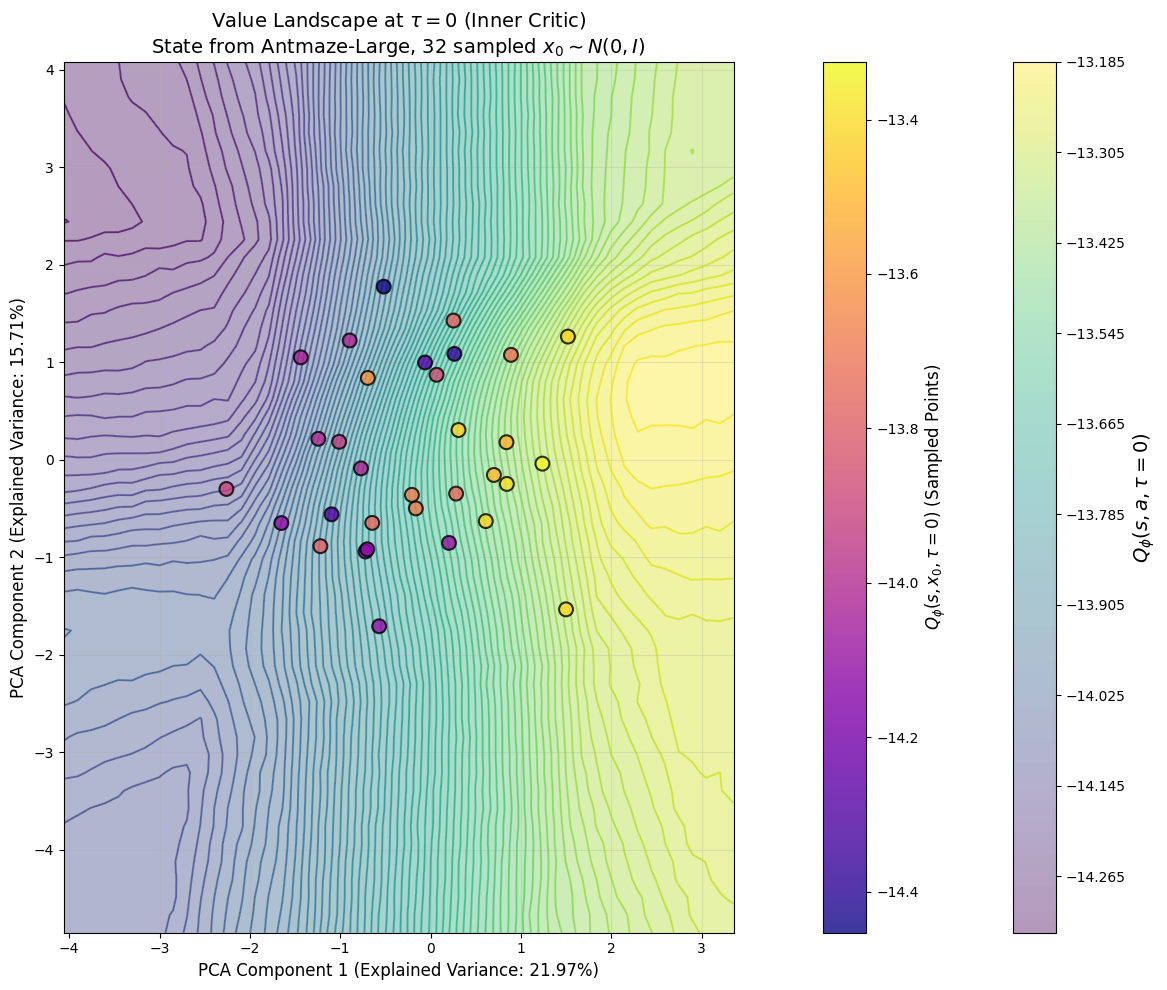


Visualization Summary:
Grid resolution: 50x50
Contour levels: 100
Sampled x_0 points: 32
PCA explained variance: 0.3768
Q value range: [-14.3259, -13.1929]
Sampled x_0 Q value range: [-14.4533, -13.3251]

Rolling out trajectories using policy...
Rolling out trajectories...


100%|██████████| 32/32 [00:05<00:00,  5.74it/s]


Trajectories shape: (32, 11, 8)
Trajectories PCA shape: (32, 11, 2)

Computing Q_grids for tau values: [0.0, 0.4, 0.6, 0.8, 1.0]
Computing Q values for tau=0.0...
  tau=0.0: Min=-14.3259, Max=-13.1929, Mean=-13.7512
Computing Q values for tau=0.4...
  tau=0.4: Min=-15.1084, Max=-13.5068, Mean=-14.2422
Computing Q values for tau=0.6...
  tau=0.6: Min=-15.5294, Max=-13.5953, Mean=-14.5182
Computing Q values for tau=0.8...
  tau=0.8: Min=-15.9545, Max=-13.9235, Mean=-14.9166
Computing Q values for tau=1.0...
  tau=1.0: Min=-16.5612, Max=-14.2377, Mean=-15.2703
Collected trajectory points for each tau value


/tmp/ipykernel_4070960/3444849476.py:452: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.9, 0.98])


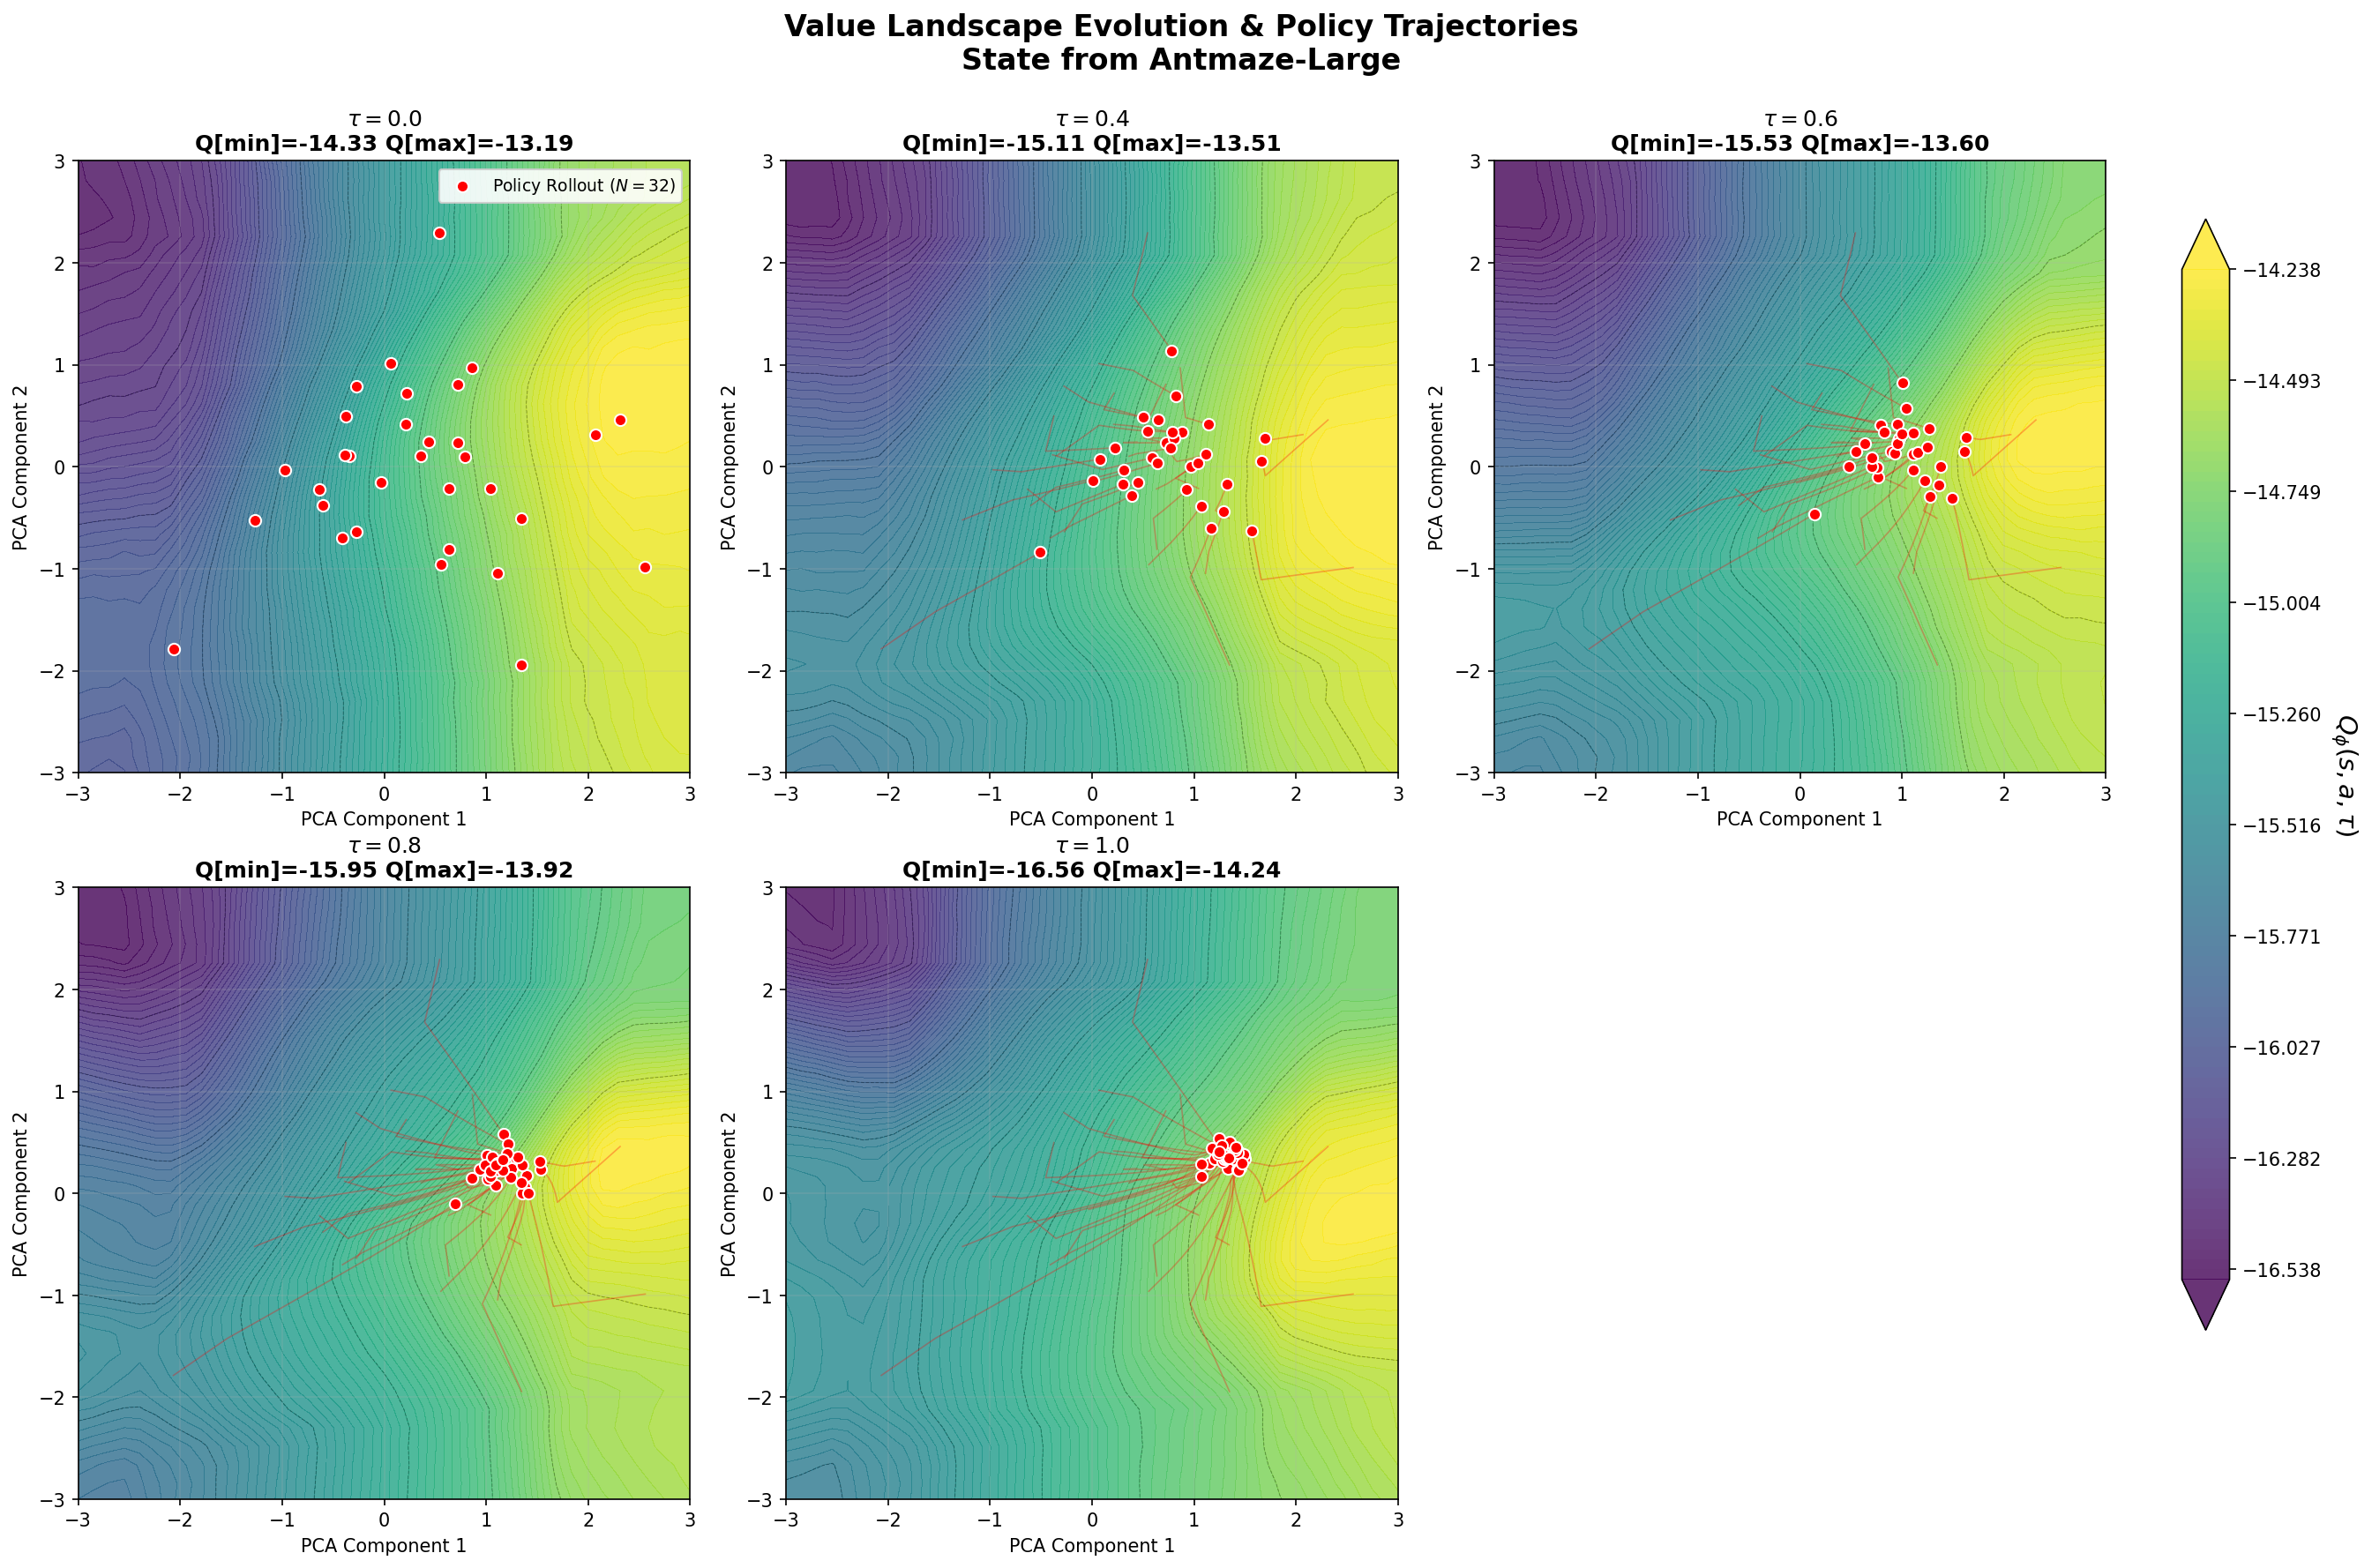

In [266]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import numpy as np
import jax.numpy as jnp

# Get action dimension
action_dim = agent.config['action_dim']
print(f"Action dimension: {action_dim}")

# Sample actions for PCA (use a diverse set of actions)
# We'll sample from both the success trajectories and from a normal distribution
num_pca_samples = 1000

# Sample from success actions (if available) and from N(0, I)|
pca_action_samples = []
try:
    if 'success_actions' in locals() and len(success_actions) > 0:
        # Use some success actions
        num_success_samples = min(500, len(success_actions))
        success_indices = np.random.choice(len(success_actions), num_success_samples, replace=False)
        pca_action_samples.append(success_actions[success_indices])
except:
    pass
    
# Add samples from N(0, I) to ensure good coverage
if len(pca_action_samples) > 0:
    used_samples = sum(len(arr) for arr in pca_action_samples)
    remaining_samples = max(0, num_pca_samples - used_samples)
else:
    remaining_samples = num_pca_samples

if remaining_samples > 0:
    normal_samples = np.random.randn(remaining_samples, action_dim)
    pca_action_samples.append(normal_samples)

# Combine all samples
if len(pca_action_samples) > 0:
    all_pca_samples = np.vstack(pca_action_samples)
else:
    all_pca_samples = np.random.randn(num_pca_samples, action_dim)
print(f"PCA samples shape: {all_pca_samples.shape}")

# Perform PCA
pca = PCA(n_components=2)
pca.fit(all_pca_samples)
pca_components = pca.components_  # Shape: (2, action_dim)
pca_mean = pca.mean_  # Shape: (action_dim,)

print(f"PCA explained variance ratio: {pca.explained_variance_ratio_}")
print(f"Total explained variance: {pca.explained_variance_ratio_.sum():.4f}")

# Function to map from 2D PCA space to full action space
def pca_to_action(pca_coords):
    """
    Map 2D PCA coordinates to full action space.
    
    Args:
        pca_coords: Array of shape (N, 2) or (2,)
    
    Returns:
        Actions of shape (N, action_dim) or (action_dim,)
    """
    pca_coords = np.array(pca_coords)
    if pca_coords.ndim == 1:
        pca_coords = pca_coords[None, :]
        squeeze = True
    else:
        squeeze = False
    
    # Project back: action = mean + pca_coords @ pca_components
    actions = pca_mean[None, :] + pca_coords @ pca_components
    actions = np.clip(actions, -1, 1)  # Clip to action bounds
    
    if squeeze:
        actions = actions[0]
    return actions

# Function to map from full action space to 2D PCA space
def action_to_pca(actions):
    """
    Map full action space to 2D PCA coordinates.
    
    Args:
        actions: Array of shape (N, action_dim) or (action_dim,)
    
    Returns:
        PCA coordinates of shape (N, 2) or (2,)
    """
    actions = np.array(actions)
    if actions.ndim == 1:
        actions = actions[None, :]
        squeeze = True
    else:
        squeeze = False
    
    # Project: pca_coords = (actions - mean) @ pca_components.T
    pca_coords = (actions - pca_mean[None, :]) @ pca_components.T
    
    if squeeze:
        pca_coords = pca_coords[0]
    return pca_coords

# Create a grid in 2D PCA space
# Determine appropriate range based on the PCA samples
pca_samples_2d = action_to_pca(all_pca_samples)
x_min, x_max = pca_samples_2d[:, 0].min(), pca_samples_2d[:, 0].max()
y_min, y_max = pca_samples_2d[:, 1].min(), pca_samples_2d[:, 1].max()

# Add some padding
x_range = x_max - x_min
y_range = y_max - y_min
x_min -= 0.1 * x_range
x_max += 0.1 * x_range
y_min -= 0.1 * y_range
y_max += 0.1 * y_range

# Create grid with good resolution (200x200 for visual precision)
resolution = 50
x_grid = np.linspace(x_min, x_max, resolution)
y_grid = np.linspace(y_min, y_max, resolution)
X_grid, Y_grid = np.meshgrid(x_grid, y_grid)

# Flatten grid for batch processing
grid_points_2d = np.stack([X_grid.ravel(), Y_grid.ravel()], axis=1)  # Shape: (resolution^2, 2)
print(f"Grid points shape: {grid_points_2d.shape}")

# Map grid points to full action space
grid_actions = pca_to_action(grid_points_2d)  # Shape: (resolution^2, action_dim)

# Compute Q values for all grid points at tau=0
print("Computing Q values for grid points...")
obs_batch = np.tile(sample_state[None, :], (len(grid_actions), 1))  # Shape: (resolution^2, obs_dim)

# Compute inner critic Q(s, a, t=0)
t_0 = jnp.full((len(grid_actions), 1), 0.0)
if time_embed is not None:
    t_feature_0 = fourier_time_embed(t_0, embed_dim=time_embed)
    q_values_flat = agent.network.select('tc_critic')(obs_batch, grid_actions, t_feature_0)
else:
    q_values_flat = agent.network.select('tc_critic')(obs_batch, grid_actions, t_0)

# Average over ensembles if needed
if q_values_flat.ndim > 1:
    q_values_flat = q_values_flat.mean(axis=0)

q_values_flat = np.array(q_values_flat)  # Shape: (resolution^2,)

# Reshape to grid
Q_grid = q_values_flat.reshape(resolution, resolution)

print(f"Q values computed. Min: {Q_grid.min():.4f}, Max: {Q_grid.max():.4f}, Mean: {Q_grid.mean():.4f}")


# np.random.seed(42)
num_samples = 32
x_0_samples = np.random.randn(num_samples, action_dim)

# Project to 2D PCA space
x_0_pca = action_to_pca(x_0_samples)  # Shape: (64, 2)

# Compute Q values for sampled x_0
obs_batch_samples = np.tile(sample_state[None, :], (num_samples, 1))
t_0_samples = jnp.full((num_samples, 1), 0.0)
if time_embed is not None:
    t_feature_0_samples = fourier_time_embed(t_0_samples, embed_dim=time_embed)
    q_values_samples = agent.network.select('tc_critic')(obs_batch_samples, x_0_samples, t_feature_0_samples)
else:
    q_values_samples = agent.network.select('tc_critic')(obs_batch_samples, x_0_samples, t_0_samples)

if q_values_samples.ndim > 1:
    q_values_samples = q_values_samples.mean(axis=0)
q_values_samples = np.array(q_values_samples)  # Shape: (64,)

# Create the visualization
fig, ax = plt.subplots(figsize=(12, 10))

# Contour plot with 100 levels
contour = ax.contour(X_grid, Y_grid, Q_grid, levels=100, cmap='viridis', alpha=0.6)

# Filled contour for better visualization
contourf = ax.contourf(X_grid, Y_grid, Q_grid, levels=100, cmap='viridis', alpha=0.4)

# Colorbar
cbar = plt.colorbar(contourf, ax=ax)
cbar.set_label(r'$Q_\phi(s, a, \tau=0)$', fontsize=14)

# Scatter plot of sampled x_0 points
scatter = ax.scatter(x_0_pca[:, 0], x_0_pca[:, 1], 
                     c=q_values_samples, 
                     s=100, 
                     cmap='plasma', 
                     edgecolors='black', 
                     linewidths=1.5,
                     alpha=0.8,
                     zorder=10)

# Colorbar for scatter points
cbar2 = plt.colorbar(scatter, ax=ax, location='right', pad=0.1)
cbar2.set_label(r'$Q_\phi(s, x_0, \tau=0)$ (Sampled Points)', fontsize=12)

# Labels and title
ax.set_xlabel(f'PCA Component 1 (Explained Variance: {pca.explained_variance_ratio_[0]:.2%})', fontsize=12)
ax.set_ylabel(f'PCA Component 2 (Explained Variance: {pca.explained_variance_ratio_[1]:.2%})', fontsize=12)
ax.set_title(f'Value Landscape at $\\tau=0$ (Inner Critic)\nState from {task_name}, {num_samples} sampled $x_0 \\sim N(0, I)$', fontsize=14)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\n{'='*60}")
print("Visualization Summary:")
print(f"{'='*60}")
print(f"Grid resolution: {resolution}x{resolution}")
print(f"Contour levels: 100")
print(f"Sampled x_0 points: {num_samples}")
print(f"PCA explained variance: {pca.explained_variance_ratio_.sum():.4f}")
print(f"Q value range: [{Q_grid.min():.4f}, {Q_grid.max():.4f}]")
print(f"Sampled x_0 Q value range: [{q_values_samples.min():.4f}, {q_values_samples.max():.4f}]")

import numpy as np
import matplotlib.pyplot as plt

# ============================================================================
# Step 1: Rollout trajectories using the policy
# ============================================================================
print(f"\n{'='*60}")
print("Rolling out trajectories using policy...")
print(f"{'='*60}")

num_trajectories = 32
flow_steps = agent.config['flow_steps']

# Sample 128 x_0 from standard normal
np.random.seed(42)
rng = jax.random.PRNGKey(42)
rng, noise_rng = jax.random.split(rng)
x_0_samples = jax.random.normal(noise_rng, (num_trajectories, action_dim))
x_0_samples = np.array(x_0_samples)

# Replicate state for all trajectories
obs_trajectories = np.tile(sample_state[None, :], (num_trajectories, 1))  # Shape: (num_trajectories, obs_dim)

# Rollout trajectories
print("Rolling out trajectories...")
trajectories = []  # List of (flow_steps+1, action_dim) arrays, one per trajectory
tau_trajectories = []  # List of (flow_steps+1,) arrays with tau values

for traj_idx in tqdm(range(num_trajectories)):
    x_t = x_0_samples[traj_idx].copy()  # Start with x_0
    traj = [x_t.copy()]  # Store initial x_0
    tau_traj = [0.0]  # tau = 0 for initial point
    
    # Rollout for flow_steps
    for step in range(flow_steps):
        tau = (step + 1) / flow_steps  # tau at next step
        t_arr = jnp.full((1, 1), step / flow_steps)  # Current time for velocity computation
        
        # Get velocity from actor (POLICY CALL)
        obs_single = obs_trajectories[traj_idx:traj_idx+1]  # Shape: (1, obs_dim)
        x_t_single = jnp.array(x_t[None, :])  # Shape: (1, action_dim)
        
        vels = agent.network.select('actor_bc_flow')(obs_single, x_t_single, t_arr)
        vels = np.array(vels[0])  # Shape: (action_dim,)
        
        # Euler step
        x_t = x_t + vels / flow_steps
        x_t = np.clip(x_t, -1, 1)  # Clip to action bounds
        
        traj.append(x_t.copy())
        tau_traj.append(tau)
    
    trajectories.append(np.array(traj))  # Shape: (flow_steps+1, action_dim)
    tau_trajectories.append(np.array(tau_traj))  # Shape: (flow_steps+1,)

trajectories = np.array(trajectories)  # Shape: (num_trajectories, flow_steps+1, action_dim)
tau_trajectories = np.array(tau_trajectories)  # Shape: (num_trajectories, flow_steps+1)

print(f"Trajectories shape: {trajectories.shape}")

# Project trajectories to 2D PCA space
trajectories_pca = []  # List of (flow_steps+1, 2) arrays
for traj in trajectories:
    traj_pca = action_to_pca(traj)  # Shape: (flow_steps+1, 2)
    trajectories_pca.append(traj_pca)

trajectories_pca = np.array(trajectories_pca)  # Shape: (num_trajectories, flow_steps+1, 2)

print(f"Trajectories PCA shape: {trajectories_pca.shape}")

# ============================================================================
# Step 2: Compute Q_grids for all tau values being plotted
# ============================================================================
tau_plot_values = [0.0, 0.4, 0.6, 0.8, 1.0]
print(f"\nComputing Q_grids for tau values: {tau_plot_values}")

Q_grids = {}
for tau in tau_plot_values:
    print(f"Computing Q values for tau={tau}...")
    
    # Compute inner critic Q(s, a, t=tau) for all grid points
    t_tau = jnp.full((len(grid_actions), 1), tau)
    
    if time_embed is not None:
        t_feature_tau = fourier_time_embed(t_tau, embed_dim=time_embed)
        q_values_flat = agent.network.select('tc_critic')(obs_batch, grid_actions, t_feature_tau)
    else:
        q_values_flat = agent.network.select('tc_critic')(obs_batch, grid_actions, t_tau)
    
    # Average over ensembles if needed
    if q_values_flat.ndim > 1:
        q_values_flat = q_values_flat.mean(axis=0)
    
    q_values_flat = np.array(q_values_flat)  # Shape: (resolution^2,)
    
    # Reshape to grid
    Q_grid = q_values_flat.reshape(resolution, resolution)
    Q_grids[tau] = Q_grid
    
    print(f"  tau={tau}: Min={Q_grid.min():.4f}, Max={Q_grid.max():.4f}, Mean={Q_grid.mean():.4f}")

# ============================================================================
# Step 3: Collect trajectory points at each tau value
# ============================================================================
trajectory_points_by_tau = {}
for tau_plot in tau_plot_values:
    trajectory_points_by_tau[tau_plot] = []
    
    for traj_idx in range(num_trajectories):
        tau_traj = tau_trajectories[traj_idx]
        closest_idx = np.argmin(np.abs(tau_traj - tau_plot))
        point_pca = trajectories_pca[traj_idx, closest_idx]  # Shape: (2,)
        trajectory_points_by_tau[tau_plot].append(point_pca)
    
    trajectory_points_by_tau[tau_plot] = np.array(trajectory_points_by_tau[tau_plot])  # Shape: (num_trajectories, 2)

print(f"Collected trajectory points for each tau value")

# ============================================================================
# Restrict value visualization to between -2 and 2, but do not clip the Q_grid itself!
# ============================================================================

# Determine plot limits based on meshgrid extents
pca_x_min, pca_x_max = X_grid.min(), X_grid.max()
pca_y_min, pca_y_max = Y_grid.min(), Y_grid.max()

# Set action limits for visualization axes (each action dim: -2 to 2)
action_vmin = -3.0
action_vmax = 3.0

tau_plot_values = [0.0, 0.4, 0.6, 0.8, 1.0]

n_tau_plot = len(tau_plot_values)
ncols_plot = min(3, n_tau_plot)
nrows_plot = (n_tau_plot + ncols_plot - 1) // ncols_plot
fig, axes = plt.subplots(nrows_plot, ncols_plot, figsize=(ncols_plot * 6, nrows_plot * 6), dpi=150)

if n_tau_plot == 1:
    axes = [axes]
else:
    axes = axes.flatten()

# Track if dots are plotted for each subplot for debug
dots_present = []

for idx, tau in enumerate(tau_plot_values):
    ax = axes[idx]
    Q_grid = Q_grids[tau]
    # Do NOT clip or restrict Q_grid values here
    # Colormap range is determined automatically from data, not forced to [-2, 2]
    q_vmin = Q_grid.min()
    q_vmax = Q_grid.max()

    # Use nan_if_outside utility for masking (if applicable)
    levels_101 = np.linspace(q_vmin, q_vmax, 101)
    levels_11 = np.linspace(q_vmin, q_vmax, 11)
    
    # Plot the landscape, match colorbar extent to value field
    contourf = ax.contourf(
        X_grid, Y_grid, Q_grid,
        levels=levels_101,
        cmap='viridis',
        vmin=q_vmin,
        vmax=q_vmax,
        alpha=0.8,
        extend='both'
    )
    
    # Contour lines for clarity
    contour = ax.contour(
        X_grid, Y_grid, Q_grid,
        levels=levels_11,
        colors='black',
        alpha=0.3,
        linewidths=0.5
    )

    # Plot trajectories: for each trajectory, plot the history up to and including tau
    plotted_any_traj = False
    for traj_idx in range(num_trajectories):
        traj_pca = trajectories_pca[traj_idx]       # (flow_steps+1, 2)
        tau_traj = tau_trajectories[traj_idx]      # (flow_steps+1,)

        # Find most recent point at tau (or just before)
        # We want points for tau_traj <= tau
        mask = tau_traj <= (tau + 1e-4)    # slight numeric tolerance
        if mask.sum() > 1:
            ax.plot(
                traj_pca[mask, 0], traj_pca[mask, 1],
                'r-', alpha=0.3, linewidth=0.8, zorder=5
            )
            plotted_any_traj = True

    # Scatter current points at this tau
    dots_ok = False
    if tau in trajectory_points_by_tau:
        points_pca = trajectory_points_by_tau[tau]
        if (points_pca.shape[0] > 0):  # Defensive: don't scatter empty
            ax.scatter(points_pca[:, 0], points_pca[:, 1],
                      c='red', s=40, alpha=1.0,
                      edgecolors='white', linewidths=1.0,
                      zorder=20, label=f'Policy Rollout ($N={num_trajectories}$)')
            dots_ok = True
    dots_present.append(dots_ok)

    # Labels and limits for axes
    ax.set_xlabel('PCA Component 1', fontsize=10)
    ax.set_ylabel('PCA Component 2', fontsize=10)
    # Print min/max of Q_grid in label for debug (to check if value field is appropriate)
    ax.set_title(f'$\\tau = {tau}$\nQ[min]={Q_grid.min():.2f} Q[max]={Q_grid.max():.2f}',
                 fontsize=12, fontweight='bold')
    ax.set_xlim([action_vmin, action_vmax])
    ax.set_ylim([action_vmin, action_vmax])
    ax.set_aspect('equal', adjustable='box')
    ax.grid(True, alpha=0.2)
    
    if idx == 0:
        ax.legend(loc='upper right', fontsize=9, framealpha=0.9)

# Hide unused subplots
for idx in range(n_tau_plot, len(axes)):
    axes[idx].axis('off')

# Shared Colorbar for the last contourf in the loop
cbar_ax = fig.add_axes([0.92, 0.15, 0.02, 0.7])
cbar = plt.colorbar(contourf, cax=cbar_ax)
cbar.set_label(r'$Q_\phi(s, a, \tau)$', fontsize=14, rotation=270, labelpad=20)

fig.suptitle(f'Value Landscape Evolution & Policy Trajectories\n'
             f'State from {task_name}', 
             fontsize=16, fontweight='bold', y=0.98)

plt.tight_layout(rect=[0, 0, 0.9, 0.98])
plt.show()

# Debug print: check if there were missing dots
for i, tau in enumerate(tau_plot_values):
    if not dots_present[i]:
        print(f"[Warning] No dots plotted for tau={tau}: "
              f"Check if trajectory_points_by_tau[{tau}] exists and has points.")


(2500, 29) (2500, 8)
Computing value landscapes for tau values: [0.0, 0.2, 0.4, 0.6, 0.8, 1.0]
Grid resolution: 50x50 = 2500 points per tau
Computing Q values for tau=0.0...
  tau=0.0: Min=-30.6599, Max=-29.7339, Mean=-30.2498
Computing Q values for tau=0.2...
  tau=0.2: Min=-30.8985, Max=-29.7295, Mean=-30.2925
Computing Q values for tau=0.4...
  tau=0.4: Min=-31.7951, Max=-29.8832, Mean=-30.8184
Computing Q values for tau=0.6...
  tau=0.6: Min=-32.7848, Max=-30.0746, Mean=-31.3465
Computing Q values for tau=0.8...
  tau=0.8: Min=-34.1333, Max=-30.2268, Mean=-31.8014
Computing Q values for tau=1.0...
  tau=1.0: Min=-35.5053, Max=-30.4126, Mean=-32.6440

Global Q value range: [-35.5053, -29.7295]


/tmp/ipykernel_4070960/432879435.py:110: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.9, 0.98])  # Leave space for colorbar


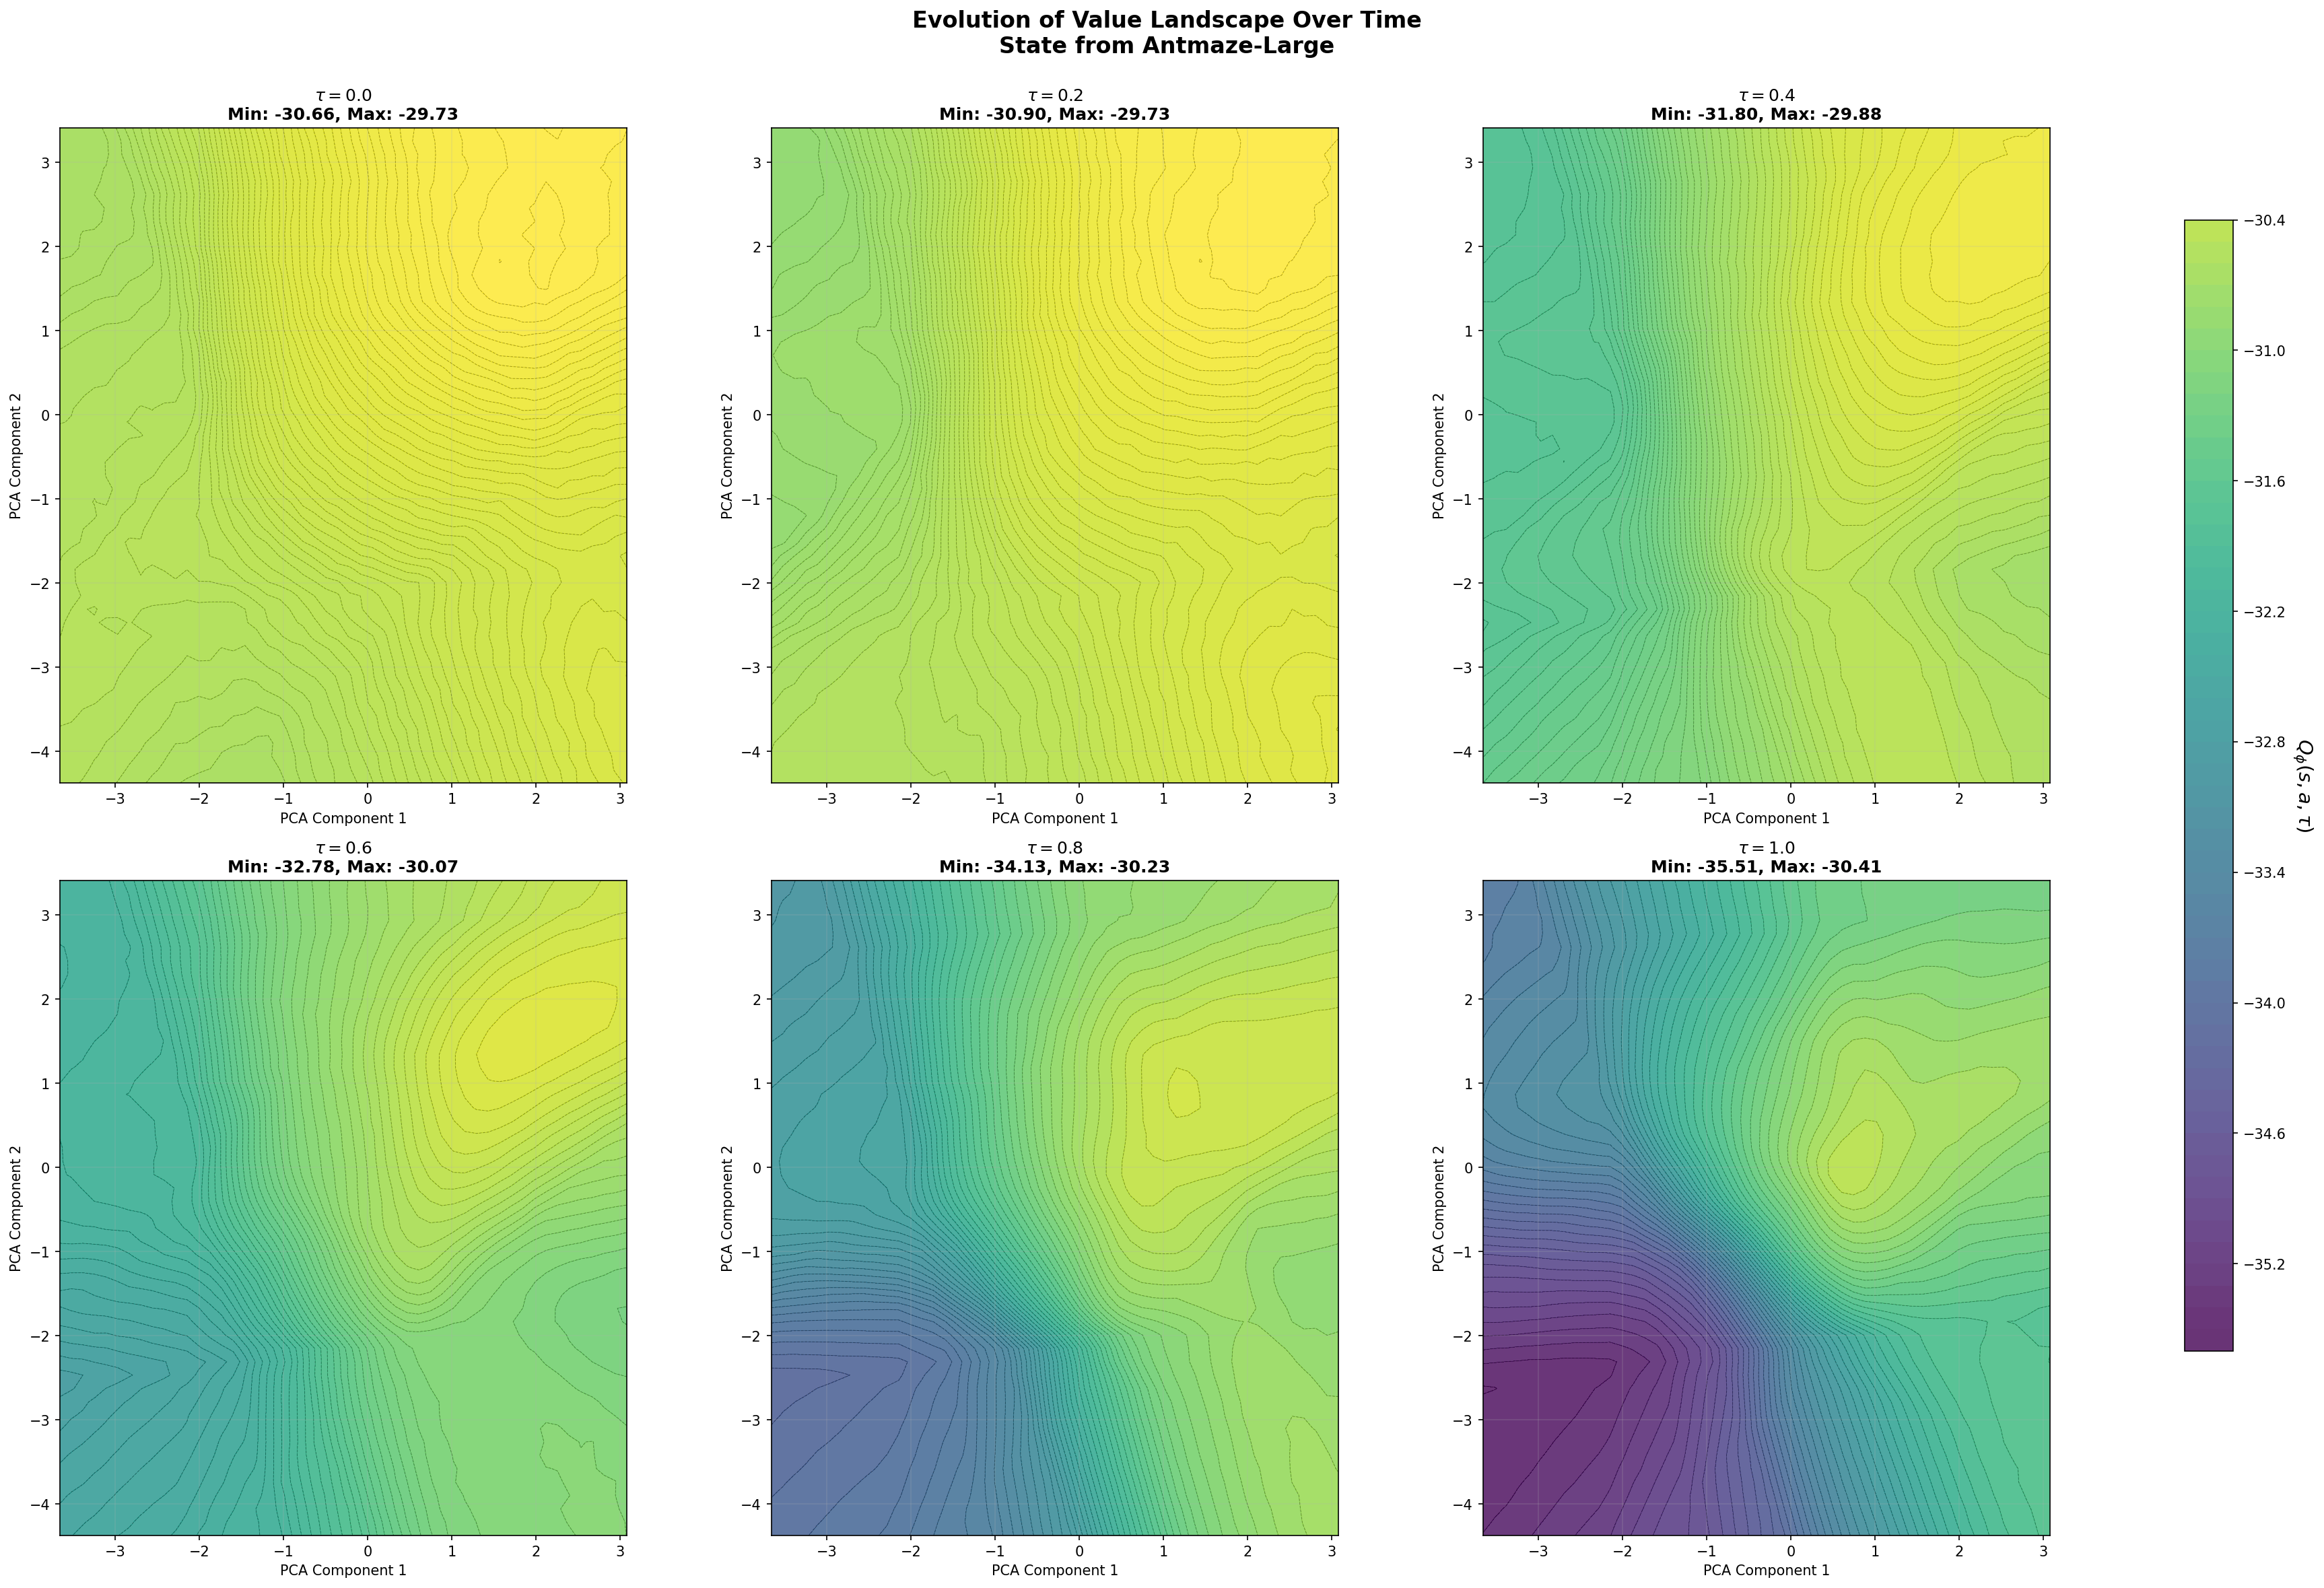


Value Landscape Evolution Summary:
tau= 0.0: Range=[-30.6599, -29.7339], Mean=-30.2498, Std=  0.2769
tau= 0.2: Range=[-30.8985, -29.7295], Mean=-30.2925, Std=  0.3388
tau= 0.4: Range=[-31.7951, -29.8832], Mean=-30.8184, Std=  0.5874
tau= 0.6: Range=[-32.7848, -30.0746], Mean=-31.3465, Std=  0.7604
tau= 0.8: Range=[-34.1333, -30.2268], Mean=-31.8014, Std=  1.2186
tau= 1.0: Range=[-35.5053, -30.4126], Mean=-32.6440, Std=  1.5370


In [252]:
# ============================================================================
# Evolution of Value Landscape Over Time (tau)
# Plot landscape at tau = 0, 0.2, 0.5, 0.7, 1.0
# ============================================================================

# Set min and max for action_dim
action_min = -1
action_max = 1

# Specify tau values to plot, or compute from flow_steps if not specified
flow_steps = agent.config['flow_steps']
tau_values = [0.0, 0.2, 0.4, 0.6, 0.8, 1.0]

num_tau = len(tau_values)

# Reuse the same grid and PCA transformation from previous cell
# (Assuming pca, X_grid, Y_grid, grid_actions, etc. are available)
print(obs_batch.shape, grid_actions.shape)

print(f"Computing value landscapes for tau values: {tau_values}")
print(f"Grid resolution: {resolution}x{resolution} = {resolution**2} points per tau")

# Enforce the grid_actions to be within the min/max action bounds
grid_actions_clipped = np.clip(grid_actions, action_min, action_max)

# Store Q values for each tau
Q_grids = {}

for tau in tau_values:
    print(f"Computing Q values for tau={tau}...")
    
    # Compute inner critic Q(s, a, t=tau) for all grid points
    t_tau = jnp.full((len(grid_actions_clipped), 1), tau)
    
    if time_embed is not None:
        t_feature_tau = fourier_time_embed(t_tau, embed_dim=time_embed)
        q_values_flat = agent.network.select('tc_critic')(obs_batch, grid_actions_clipped, t_feature_tau)
    else:
        q_values_flat = agent.network.select('tc_critic')(obs_batch, grid_actions_clipped, t_tau)
    
    # Average over ensembles if needed
    if q_values_flat.ndim > 1:
        q_values_flat = q_values_flat.mean(axis=0)
    
    q_values_flat = np.array(q_values_flat)  # Shape: (resolution^2,)
    
    # Reshape to grid
    Q_grid = q_values_flat.reshape(resolution, resolution)
    Q_grids[tau] = Q_grid
    
    print(f"  tau={tau}: Min={Q_grid.min():.4f}, Max={Q_grid.max():.4f}, Mean={Q_grid.mean():.4f}")

# Find global min/max for consistent colorbar scaling
all_q_values = np.concatenate([Q_grids[tau].ravel() for tau in tau_values])
q_min_global = all_q_values.min()
q_max_global = all_q_values.max()

print(f"\nGlobal Q value range: [{q_min_global:.4f}, {q_max_global:.4f}]")

# Create subplot grid: dynamically size based on number of tau values
n_tau = len(tau_values)
ncols = min(3, n_tau)  # Max 6 columns
nrows = (n_tau + ncols - 1) // ncols  # Ceiling division
fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 8, nrows * 8), dpi=150)
if n_tau == 1:
    axes = [axes]
else:
    axes = axes.flatten()

# Plot each tau value
for idx, tau in enumerate(tau_values):
    ax = axes[idx]
    Q_grid = Q_grids[tau]
    
    # Contour plot with 100 levels
    contourf = ax.contourf(X_grid, Y_grid, Q_grid, 
                           levels=50, 
                           cmap='viridis', 
                           vmin=q_min_global, 
                           vmax=q_max_global,
                           alpha=0.8)
    
    # Contour lines (fewer for clarity)
    contour = ax.contour(X_grid, Y_grid, Q_grid, 
                        levels=50, 
                        colors='black', 
                        alpha=0.3, 
                        linewidths=0.5)
    
    ax.set_xlabel(f'PCA Component 1', fontsize=10)
    ax.set_ylabel(f'PCA Component 2', fontsize=10)
    ax.set_title(f'$\\tau = {tau}$\nMin: {Q_grid.min():.2f}, Max: {Q_grid.max():.2f}', 
                 fontsize=12, fontweight='bold')
    ax.grid(True, alpha=0.2)
    ax.set_aspect('equal', adjustable='box')

# Hide unused subplots
for idx in range(n_tau, len(axes)):
    axes[idx].axis('off')

# Add a shared colorbar
cbar_ax = fig.add_axes([0.92, 0.15, 0.02, 0.7])  # [left, bottom, width, height]
cbar = plt.colorbar(contourf, cax=cbar_ax)
cbar.set_label(r'$Q_\phi(s, a, \tau)$', fontsize=14, rotation=270, labelpad=20)

# Main title
fig.suptitle(f'Evolution of Value Landscape Over Time\nState from {task_name}', 
             fontsize=16, fontweight='bold', y=0.98)

plt.tight_layout(rect=[0, 0, 0.9, 0.98])  # Leave space for colorbar
plt.show()

# Print summary statistics
print(f"\n{'='*60}")
print("Value Landscape Evolution Summary:")
print(f"{'='*60}")
for tau in tau_values:
    Q_grid = Q_grids[tau]
    print(f"tau={tau:4.1f}: Range=[{Q_grid.min():8.4f}, {Q_grid.max():8.4f}], "
          f"Mean={Q_grid.mean():8.4f}, Std={Q_grid.std():8.4f}")
